In [91]:
# =========================================================
# XGBOOST FOR HORSE AUCTION PRICE PREDICTION
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print(f"XGBoost version: {xgb.__version__}")

# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------
def find_col(df, candidates):
    """Find column by exact, case-insensitive, or substring match."""
    cols = list(df.columns)
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

def to_numeric_safe(series):
    """Convert series to numeric, handling various formats."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace("\u00a0", "", regex=False)
              .str.replace(" ", "", regex=False)
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )



# ---------------------------------------------------------
# Load and prepare data
# ---------------------------------------------------------
print("="*70)
print("DATA PREPARATION")
print("="*70)

df = pd.read_excel("Yearlingauctiondata.xlsx")
df.columns = [c.strip() for c in df.columns]
print(f"\nLoaded {len(df)} rows")

# Identify columns
col_price = find_col(df, ["Sales Price", "Hammer Price", "Price"])
col_studfee = find_col(df, ["Sire Stud Fee", "Stud Fee"])
col_dam_earnings = find_col(df, ["Dam Earnings"])
col_dam_best = find_col(df, ["Dam Best Time", "Dam Best"])
col_dam_starts = find_col(df, ["Dam Starts"])
col_dam_1st = find_col(df, ["Dam 1st"])
col_dam_age = find_col(df, ["Dam Age"])
col_age = find_col(df, ["Age in days", "Age"])
col_year = find_col(df, ["Year", "Auction Year"])
col_gender = find_col(df, ["Gender", "Sex"])
col_auction = find_col(df, ["Auction", "Auction House"])
col_siblings_raceage = find_col(df, ["Siblings Raceage"])
col_american_stakes = "American Stakes"  
col_surgery_report = "Surgery Certificate"
col_surgery_severity = "Surgery Severity"
col_xray_status = 'OCD_XRAY'
col_xray_remains = 'Xray_REM'
col_breeder = 'Breeder'
col_dam_sire = 'Dams_Sire'
col_sire_first_season = find_col(df, ["First_Season_Flag"])
col_sire_starts = find_col(df, ["Sire Starts"])
col_sire_earnings = find_col(df, ["Sire Earnings"]) 
col_sire_1st = find_col(df, ["Sire 1st"])
col_dam_sire = find_col(df, ["Dams_Sire"])
col_year = find_col(df, ["Year"])



# BLUP columns
col_dam_blup = find_col(df, ["Dam BLUP", "Dam_BLUP", "DamBLUP"])
col_sire_blup = find_col(df, ["Sire BLUP", "Sire_BLUP", "SireBLUP"])
col_dam_sire_blup = find_col(df, ["Dam Sire BLUP", "Dam_Sire_BLUP", "DamSireBLUP", "Damsire BLUP"])

print(f"\n[BLUP COLUMNS FOUND]")
print(f"  Dam BLUP:      {col_dam_blup}")
print(f"  Sire BLUP:     {col_sire_blup}")
print(f"  Dam Sire BLUP: {col_dam_sire_blup}")



# ---------------------------------------------------------
# Convert columns to numeric
# ---------------------------------------------------------
print("\n[CONVERTING COLUMNS TO NUMERIC]")
numeric_candidates = [
    col_price, col_studfee, col_dam_earnings, col_dam_best, 
    col_dam_starts, col_dam_1st, col_dam_age, col_age, col_siblings_raceage,
    "French Blood", "Inbreeding", "Sibling Earnings", "Sibling Starts",
    "Sibling 1st", "Gdam  Earnings", "Gdam Raceage", "Gdam Offspring 1st",
    "Gdam Offspring Starts", "Ggdam Earnings", "Ggdam Raceage",
    "Ggdam Offspring 1st", "Ggdam Offspring Starts",
    col_dam_blup, col_sire_blup, col_dam_sire_blup, col_year
]

for col in numeric_candidates:
    if col and col in df.columns:
        if df[col].dtype == 'object':
            print(f"  Converting: {col}")
        df[col] = to_numeric_safe(df[col])

# Target variable
df["Log_price"] = np.log(df[col_price])

#Log transform Stud fee 
df["Log_stud_fee"] = np.log(df[col_studfee])

# ---------------------------------------------------------
# Feature Engineering
# ---------------------------------------------------------
print("\n[FEATURE ENGINEERING]")

# Dam performance - KEEP NaN for XGBoost to handle
# Only calculate if dam has raced
df["DamWinPct"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_1st] / df[col_dam_starts],
    np.nan  # Let XGBoost handle missing
)

# Binary indicator for dam never raced
df["Dam_Never_Raced"] = (df[col_dam_starts].isna() | (df[col_dam_starts] == 0)).astype(int)


# Dam earnings pr start 
df["DamEarningsPerStart"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_earnings] / df[col_dam_starts],
    np.nan
)


# Sibling performance - KEEP NaN for missing
df["SiblingEarningsPerStart"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling Earnings"] / df["Sibling Starts"],
    np.nan
)

df["SiblingEarningsPerHorse"] = np.where(
    df[col_siblings_raceage] > 0,
    df["Sibling Earnings"] / df[col_siblings_raceage],
    np.nan
)

df["SiblingWinPct"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling 1st"] / df["Sibling Starts"],
    np.nan
)

# Binary indicator for no siblings
df["Siblings_Missing"] = (df[col_siblings_raceage].isna() | (df[col_siblings_raceage] == 0)).astype(int)

# Granddam performance
df["GranddamEarningsPerHorse"] = np.where(
    df["Gdam Raceage"] > 0,
    df["Gdam  Earnings"] / df["Gdam Raceage"],
    np.nan
)

df["GranddamWinPct"] = np.where(
    df["Gdam Offspring Starts"] > 0,
    df["Gdam Offspring 1st"] / df["Gdam Offspring Starts"],
    np.nan
)

# Great-granddam performance
df["GD_Dam_EarningsPerHorse"] = np.where(
    df["Ggdam Raceage"] > 0,
    df["Ggdam Earnings"] / df["Ggdam Raceage"],
    np.nan
)

df["GD_Dam_WinPct"] = np.where(
    df["Ggdam Offspring Starts"] > 0,
    df["Ggdam Offspring 1st"] / df["Ggdam Offspring Starts"],
    np.nan
)

# Sire performance

df["SireWinPct"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_1st] / df[col_sire_starts],
    np.nan
)

df["SireEarningsPerStart"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_earnings] / df[col_sire_starts],
    np.nan
)

#Inverse dam time so that sign is interpretable 
df['dam_time_inverse'] = 1 / df['Dam Best Time']


# Prize money impact 
prize_money_sek = {
    2023: 1.0,
    2024: 1.25,
    2025: 1.30
}

df["Log_Prize_Money"] = np.log(df[col_year].map(prize_money_sek))



# BLUP missing indicators
if col_dam_blup and col_dam_blup in df.columns:
    df["Dam_BLUP_Missing"] = df[col_dam_blup].isna().astype(int)
if col_sire_blup and col_sire_blup in df.columns:
    df["Sire_BLUP_Missing"] = df[col_sire_blup].isna().astype(int)
if col_dam_sire_blup and col_dam_sire_blup in df.columns:
    df["Dam_Sire_BLUP_Missing"] = df[col_dam_sire_blup].isna().astype(int)

# Categorical encoding
df[col_auction] = df[col_auction].astype(str).str.strip().str.upper()
df["Selective_Auctions"] = df[col_auction].isin(["EY", "SY"]).astype(int)

df[col_gender] = df[col_gender].astype(str).str.strip().str.upper()
df["Gender"] = (df[col_gender] == "H").astype(int)



# ---------------------------------------------------------
# XRAY_RISK_SCORE (deterministic feature)
# ---------------------------------------------------------
print("  Creating XRAY_RISK_SCORE")

# Ensure numeric types (in case they come in as object)
for c in [col_xray_status, col_surgery_report, col_surgery_severity, col_xray_remains]:
    if c in df.columns:
        df[c] = to_numeric_safe(df[c])

# Normalize: SURGERY_SEVERITY should be NaN when no surgery certificate
# (so '0' doesn't carry meaning beyond "not applicable")
if col_surgery_report in df.columns and col_surgery_severity in df.columns:
    df.loc[df[col_surgery_report] == 0, col_surgery_severity] = np.nan

# Compute score components (monotone, clamped to [0,1])
base_risk = np.where(df[col_xray_status] == 1, 0.40, 0.00)
surgery_mitigation = np.where(df[col_surgery_report] == 1, -0.10, 0.00)

# disease burden: only if severity exists (3-5). If NaN -> 0.0
# disease burden (severity)

severity_map = {
    3: 0.10,
    4: 0.30,
    5: 0.60
}

severity_risk = df[col_surgery_severity].map(severity_map).fillna(0.0)



# residual risk: X_RAY_REM assumed 0-3; if missing -> 0 (or NaN if you prefer)
rem = df[col_xray_remains].fillna(0.0)
residual_risk = 0.15 * rem

df["XRAY_RISK_SCORE"] = base_risk + surgery_mitigation + severity_risk + residual_risk
df["XRAY_RISK_SCORE"] = df["XRAY_RISK_SCORE"].clip(lower=0.0, upper=1.0)


print("  Created derived features")


XGBoost version: 3.0.2
DATA PREPARATION

Loaded 1618 rows

[BLUP COLUMNS FOUND]
  Dam BLUP:      Dam BLUP
  Sire BLUP:     Sire BLUP
  Dam Sire BLUP: Dam Sire BLUP

[CONVERTING COLUMNS TO NUMERIC]
  Converting: French Blood
  Converting: Inbreeding

[FEATURE ENGINEERING]
  Creating XRAY_RISK_SCORE
  Created derived features


In [93]:
# ---------------------------------------------------------
# Train/Test Split
# ---------------------------------------------------------
TRAIN_YEARS = [2023, 2024]
TEST_YEAR = 2025



train_mask = df[col_year].isin(TRAIN_YEARS)
test_mask = df[col_year] == TEST_YEAR

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

y_train = df_train["Log_price"].copy()
y_test = df_test["Log_price"].copy()

# Store indices
train_indices = df_train.index
test_indices = df_test.index

print(f"[SPLIT]")
print(f"  Train: {len(df_train)} rows ({TRAIN_YEARS})")
print(f"  Test: {len(df_test)} rows ({TEST_YEAR})")

[SPLIT]
  Train: 1108 rows ([2023, 2024])
  Test: 510 rows (2025)


In [95]:
# =========================================================
# BREEDER - SMOOTHED TARGET ENCODING (with LOO for training)
# =========================================================

print("="*70)
print("BREEDER - SMOOTHED TARGET ENCODING")
print("="*70)

# ---------------------------------------------------------
# 1. Calculate breeder statistics on TRAINING DATA
# ---------------------------------------------------------
target = 'Log_price'

# Global mean from training data
global_mean_breeder = df_train[target].mean()

# Breeder-level statistics from training data
breeder_stats = df_train.groupby(col_breeder)[target].agg(['sum', 'count', 'std'])
breeder_stats.columns = ['breeder_sum', 'n', 'breeder_std']
breeder_stats['breeder_mean'] = breeder_stats['breeder_sum'] / breeder_stats['n']

print(f"\n[BREEDER STATISTICS (from training data)]")
print(f"  Unique breeders in train: {len(breeder_stats)}")
print(f"  Global mean (Log_price):  {global_mean_breeder:.4f}")
print(f"\n  Breeder count distribution:")
print(f"    1 horse:     {(breeder_stats['n'] == 1).sum()} breeders")
print(f"    2-5 horses:  {((breeder_stats['n'] >= 2) & (breeder_stats['n'] <= 5)).sum()} breeders")
print(f"    6-10 horses: {((breeder_stats['n'] >= 6) & (breeder_stats['n'] <= 10)).sum()} breeders")
print(f"    11+ horses:  {(breeder_stats['n'] > 10).sum()} breeders")

# ---------------------------------------------------------
# 2. Calculate smoothing parameter (Empirical Bayes)
# ---------------------------------------------------------
global_var = df_train[target].var()
within_var = breeder_stats['breeder_std'].mean() ** 2
m_breeder = global_var / within_var if within_var > 0 else 5

print(f"\n[SMOOTHING PARAMETER]")
print(f"  Empirical Bayes m: {m_breeder:.2f}")

# ---------------------------------------------------------
# 3. TRAINING DATA: Leave-One-Out Encoding
# ---------------------------------------------------------
train_breeder_sum = df_train[col_breeder].map(breeder_stats['breeder_sum'])
train_breeder_n = df_train[col_breeder].map(breeder_stats['n'])

# LOO mean: (sum - this_horse_price) / (n - 1)
loo_mean = (train_breeder_sum - df_train[target]) / (train_breeder_n - 1)
loo_mean = loo_mean.fillna(global_mean_breeder)

# Effective sample size for smoothing
loo_n = (train_breeder_n - 1).clip(lower=0)

# Apply smoothing
df_train['Breeder_Encoded'] = (loo_n * loo_mean + m_breeder * global_mean_breeder) / (loo_n + m_breeder)
df_train['Breeder_Encoded'] = df_train['Breeder_Encoded'].fillna(global_mean_breeder)

print(f"\n[TRAINING DATA: Leave-One-Out Encoding Applied]")

# ---------------------------------------------------------
# 4. TEST DATA: Standard Encoding
# ---------------------------------------------------------
def smoothed_target_encode(df, col, stats, global_mean, m):
    n = df[col].map(stats['n']).fillna(0)
    breeder_mean = df[col].map(stats['breeder_mean']).fillna(global_mean)
    encoded = (n * breeder_mean + m * global_mean) / (n + m)
    return encoded.fillna(global_mean)

df_test['Breeder_Encoded'] = smoothed_target_encode(
    df_test, col_breeder, breeder_stats, global_mean_breeder, m_breeder
)

# New breeders check
new_breeders = set(df_test[col_breeder]) - set(df_train[col_breeder])
print(f"\n[TEST DATA: Standard Encoding Applied]")
print(f"  New breeders in test: {len(new_breeders)} (will use global mean)")

# ---------------------------------------------------------
# 5. Summary
# ---------------------------------------------------------
print(f"\n[CORRELATION WITH Log_price]")
print(f"  Train (LOO): r = {df_train['Breeder_Encoded'].corr(df_train['Log_price']):+.4f}")
print(f"  Test:        r = {df_test['Breeder_Encoded'].corr(df_test['Log_price']):+.4f}")

print(f"\n✓ Breeder_Encoded added to df_train and df_test")

BREEDER - SMOOTHED TARGET ENCODING

[BREEDER STATISTICS (from training data)]
  Unique breeders in train: 309
  Global mean (Log_price):  11.7590

  Breeder count distribution:
    1 horse:     147 breeders
    2-5 horses:  119 breeders
    6-10 horses: 26 breeders
    11+ horses:  17 breeders

[SMOOTHING PARAMETER]
  Empirical Bayes m: 2.22

[TRAINING DATA: Leave-One-Out Encoding Applied]

[TEST DATA: Standard Encoding Applied]
  New breeders in test: 61 (will use global mean)

[CORRELATION WITH Log_price]
  Train (LOO): r = +0.4021
  Test:        r = +0.2988

✓ Breeder_Encoded added to df_train and df_test


In [97]:
# ---------------------------------------------------------
# Define feature list (including BLUP)
# ---------------------------------------------------------
FEATURES = [
    # Core features
    "French Blood",
    "Inbreeding",
    col_age,
    col_american_stakes,
 #   col_surgery_report,
 #   col_surgery_severity,
 #    col_xray_status,
 #   col_xray_remains,
    "XRAY_RISK_SCORE",

 #Sire Features
   # col_studfee,
    "Log_stud_fee",    
    col_sire_first_season,
 #    "SireWinPct",
    "SireEarningsPerStart",
    
    # Dam features 
   # col_dam_earnings,
   # col_dam_best,
   "dam_time_inverse",
    "DamWinPct",
    "DamEarningsPerStart",
   col_dam_age,
  #  col_dam_starts,
    
    # BLUP features
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    
    # Sibling features
   # "Sibling Earnings",
   # "Sibling Starts",
 #   col_siblings_raceage,
    "SiblingEarningsPerStart",
    "SiblingEarningsPerHorse",
    "SiblingWinPct",
    
    # Granddam features
    #"Gdam  Earnings",
    "GranddamEarningsPerHorse",
    "GranddamWinPct",
    
    # Great-granddam features
    #"Ggdam Earnings",
    "GD_Dam_EarningsPerHorse",
    "GD_Dam_WinPct",
    
    # Categorical/Binary
    "Gender",
    "Selective_Auctions",
    "Dam_Never_Raced",
    "Siblings_Missing",
#    "Log_Prize_Money",
    
     # BREEDER
    "Breeder_Encoded",

]

# Add BLUP missing indicators if BLUP columns exist
if col_dam_blup and col_dam_blup in df.columns:
    FEATURES.append("Dam_BLUP_Missing")
if col_sire_blup and col_sire_blup in df.columns:
    FEATURES.append("Sire_BLUP_Missing")
if col_dam_sire_blup and col_dam_sire_blup in df.columns:
    FEATURES.append("Dam_Sire_BLUP_Missing")

# Filter to existing columns
FEATURES = [f for f in FEATURES if f and f in df_train.columns]
print(f"\n[FEATURES] {len(FEATURES)} features selected")
for f in FEATURES:
    print(f"  - {f}")


# ---------------------------------------------------------
# Create feature matrices
# ---------------------------------------------------------
X_train = df_train[FEATURES].copy()
X_test = df_test[FEATURES].copy()

# Convert any remaining object columns
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        print(f"  Converting {col} to numeric")
        X_train[col] = to_numeric_safe(X_train[col])
        X_test[col] = to_numeric_safe(X_test[col])

# Handle infinities (but KEEP NaN for XGBoost!)
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Final verification
object_cols = X_train.select_dtypes(include=['object']).columns.tolist()
if object_cols:
    print(f"  WARNING: Still have object columns: {object_cols}")
else:
    print("\n  ✓ All columns are numeric")

print(f"\n[FEATURE MATRICES]")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")


[FEATURES] 30 features selected
  - French Blood
  - Inbreeding
  - Age in days
  - American Stakes
  - XRAY_RISK_SCORE
  - Log_stud_fee
  - First_Season_Flag
  - SireEarningsPerStart
  - dam_time_inverse
  - DamWinPct
  - DamEarningsPerStart
  - Dam Age
  - Dam BLUP
  - Sire BLUP
  - Dam Sire BLUP
  - SiblingEarningsPerStart
  - SiblingEarningsPerHorse
  - SiblingWinPct
  - GranddamEarningsPerHorse
  - GranddamWinPct
  - GD_Dam_EarningsPerHorse
  - GD_Dam_WinPct
  - Gender
  - Selective_Auctions
  - Dam_Never_Raced
  - Siblings_Missing
  - Breeder_Encoded
  - Dam_BLUP_Missing
  - Sire_BLUP_Missing
  - Dam_Sire_BLUP_Missing

  ✓ All columns are numeric

[FEATURE MATRICES]
  X_train: (1108, 30)
  X_test:  (510, 30)


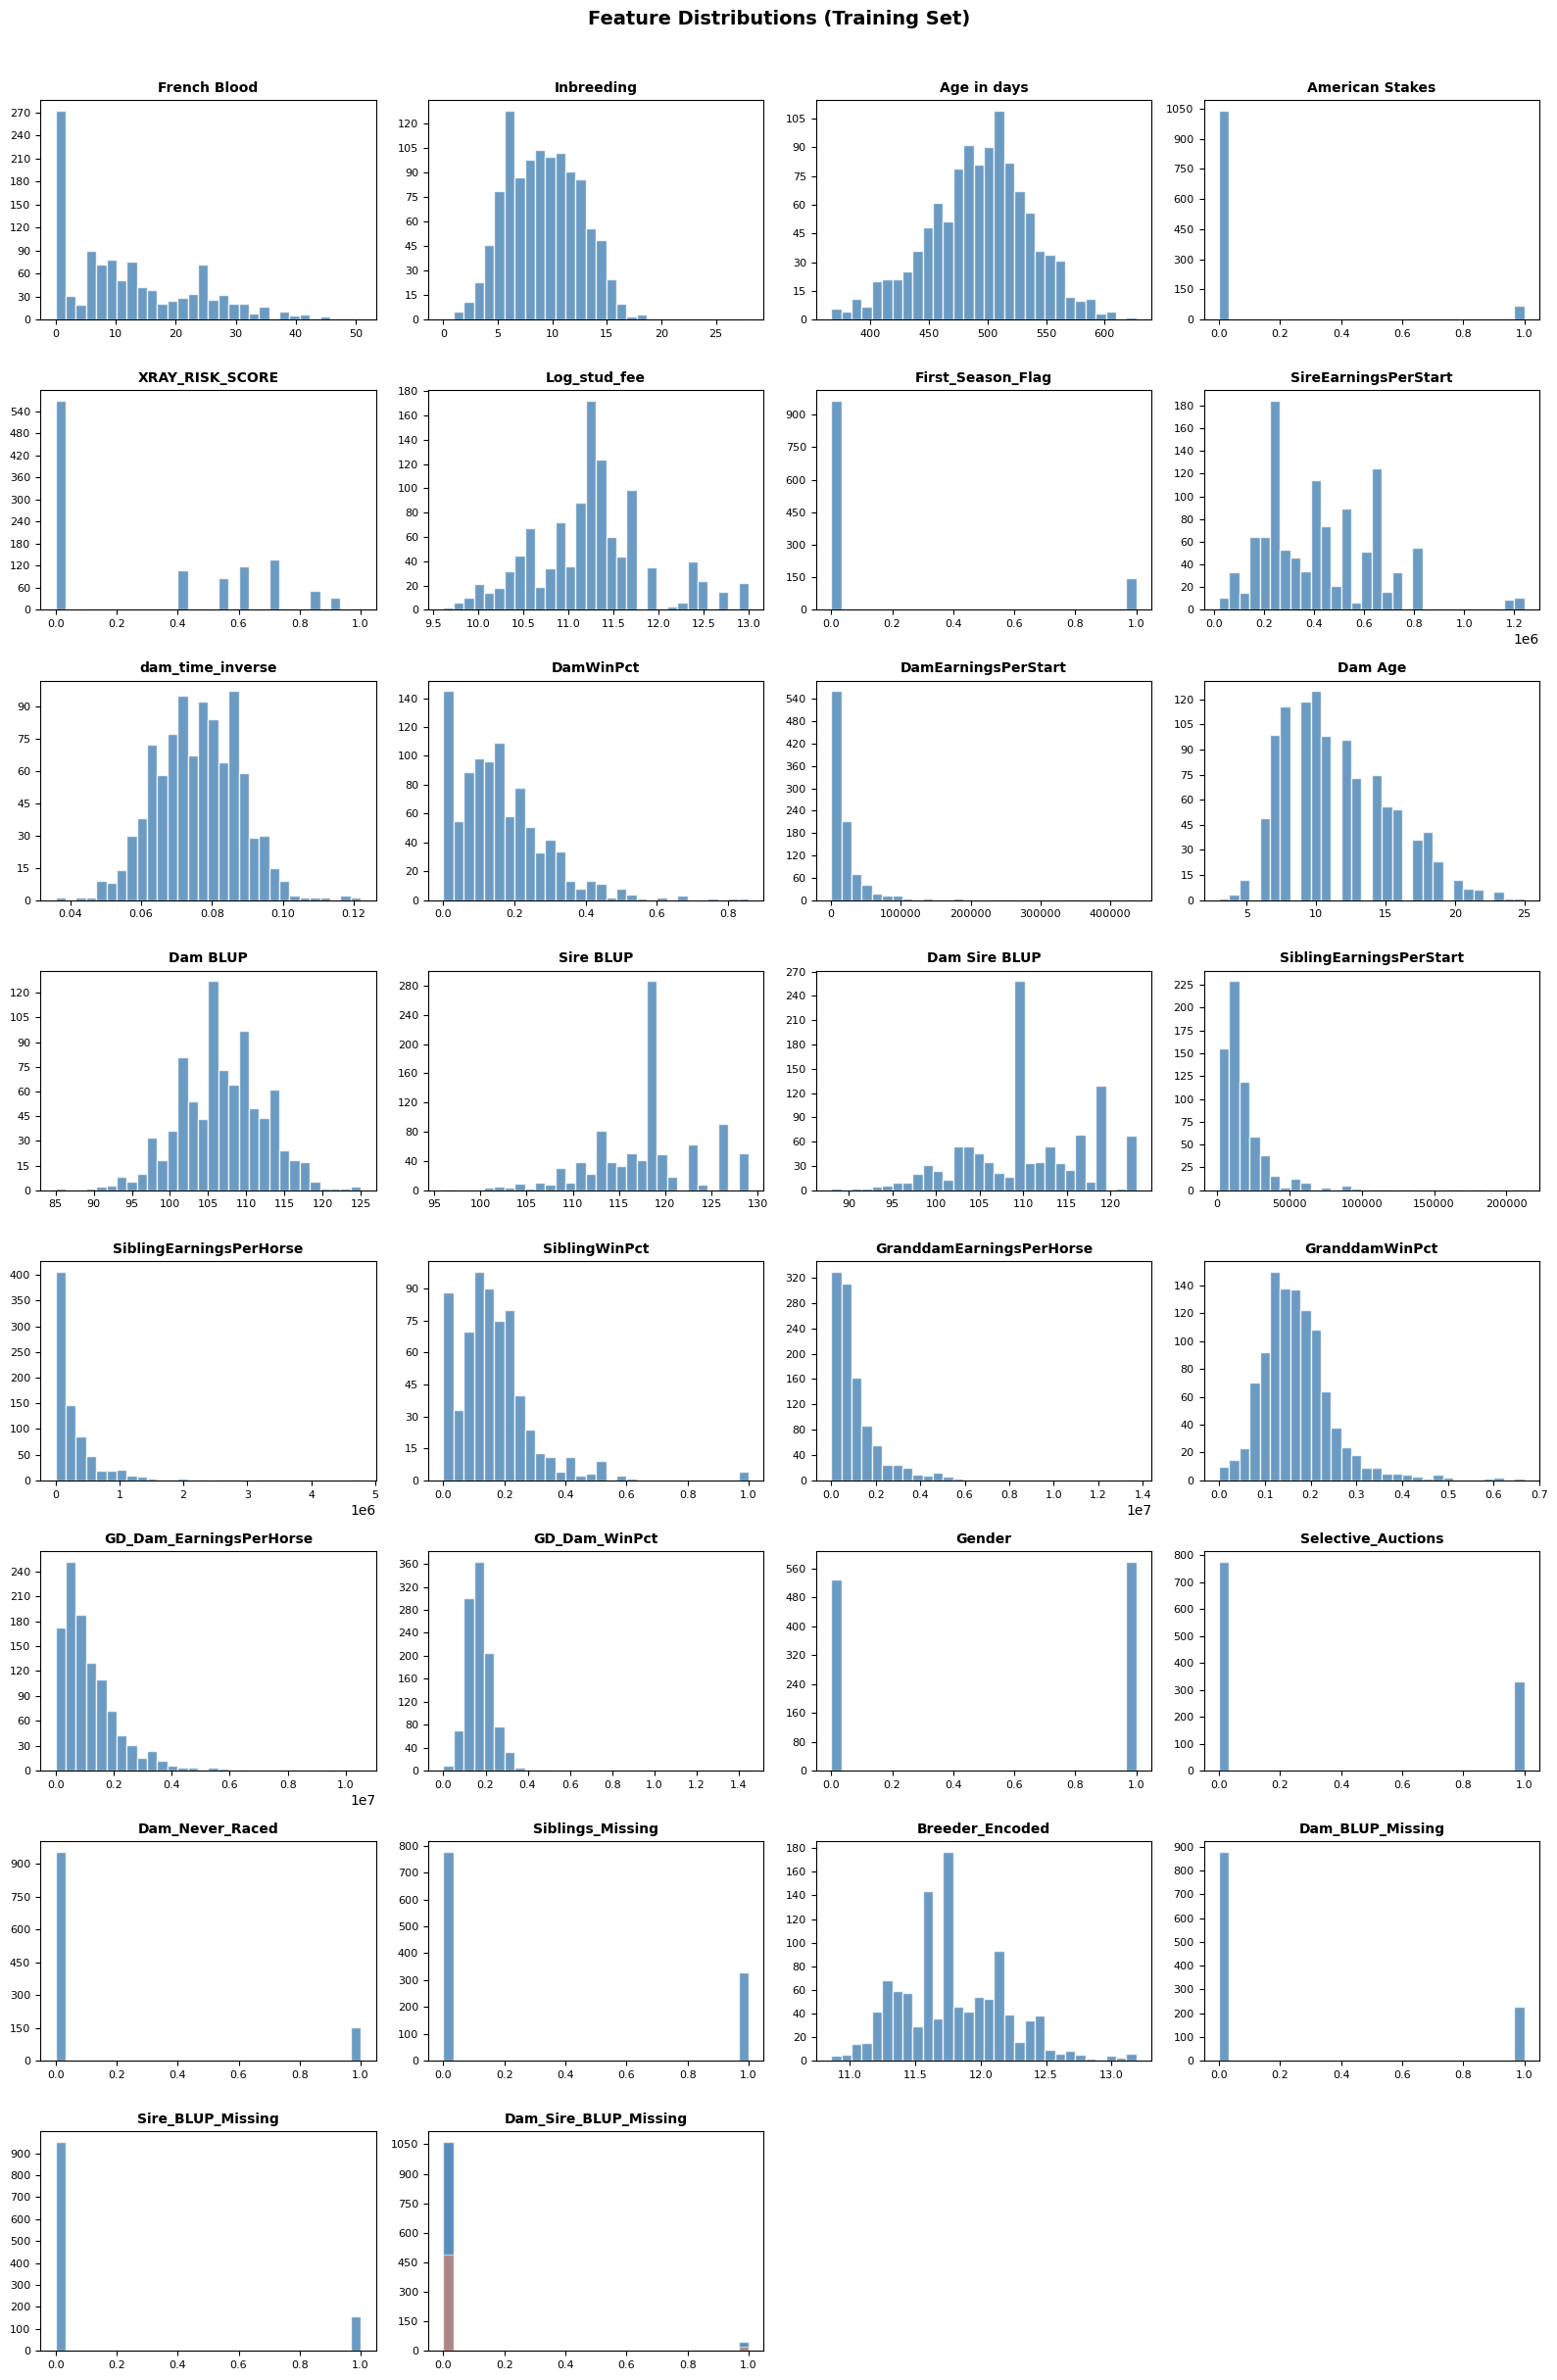

In [99]:
# =========================================================
# FEATURE DISTRIBUTIONS (TEST ONLY
# =========================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

n_features = len(FEATURES)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(df_train[feat].dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Hide unused subplots
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)


ax.hist(df_train[feat].dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.5, label="Train")
ax.hist(df_test[feat].dropna(),  bins=30, color="coral",     edgecolor="white", alpha=0.5, label="Test")

fig.suptitle("Feature Distributions (Training Set)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig('Feature_Distributions.svg', dpi=150, bbox_inches='tight')
plt.show()

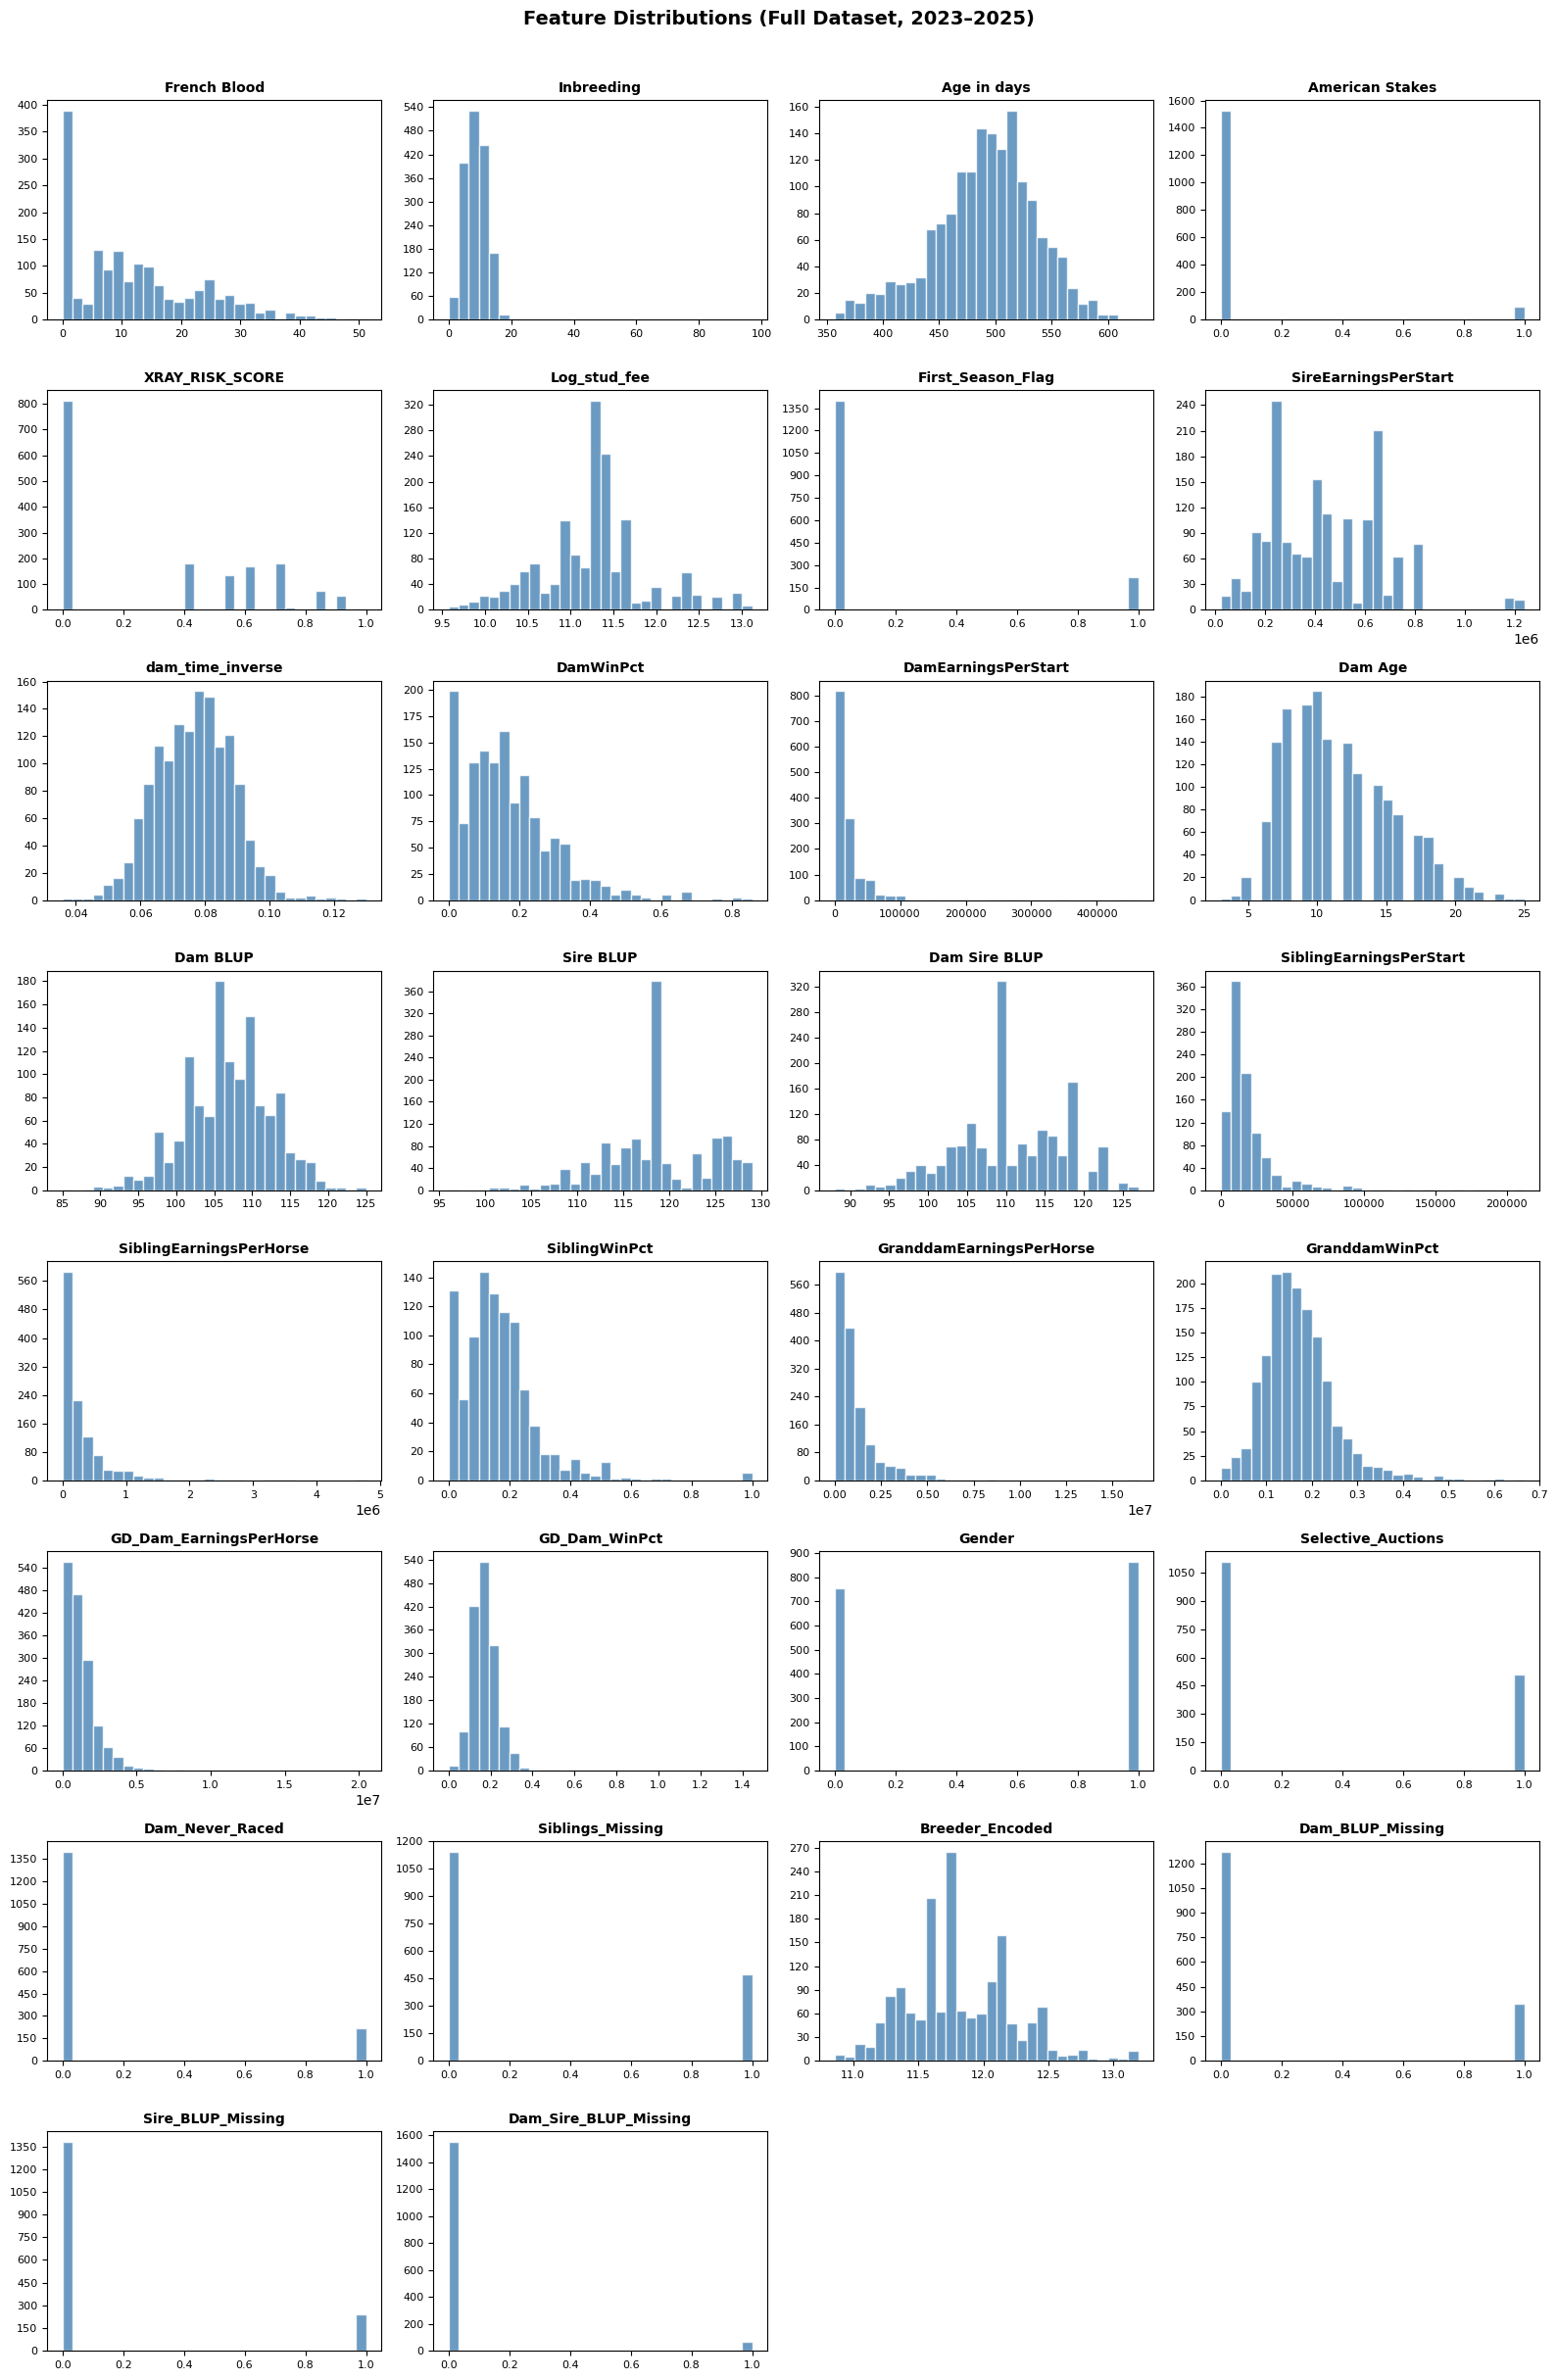

In [100]:
# =========================================================
# FEATURE DISTRIBUTIONS (FULL DATASET)
# =========================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df_full = pd.concat([df_train, df_test], ignore_index=True)

n_features = len(FEATURES)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(df_full[feat].dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions (Full Dataset, 2023–2025)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig('Feature_Distributions.svg', dpi=150, bbox_inches='tight')
plt.show()

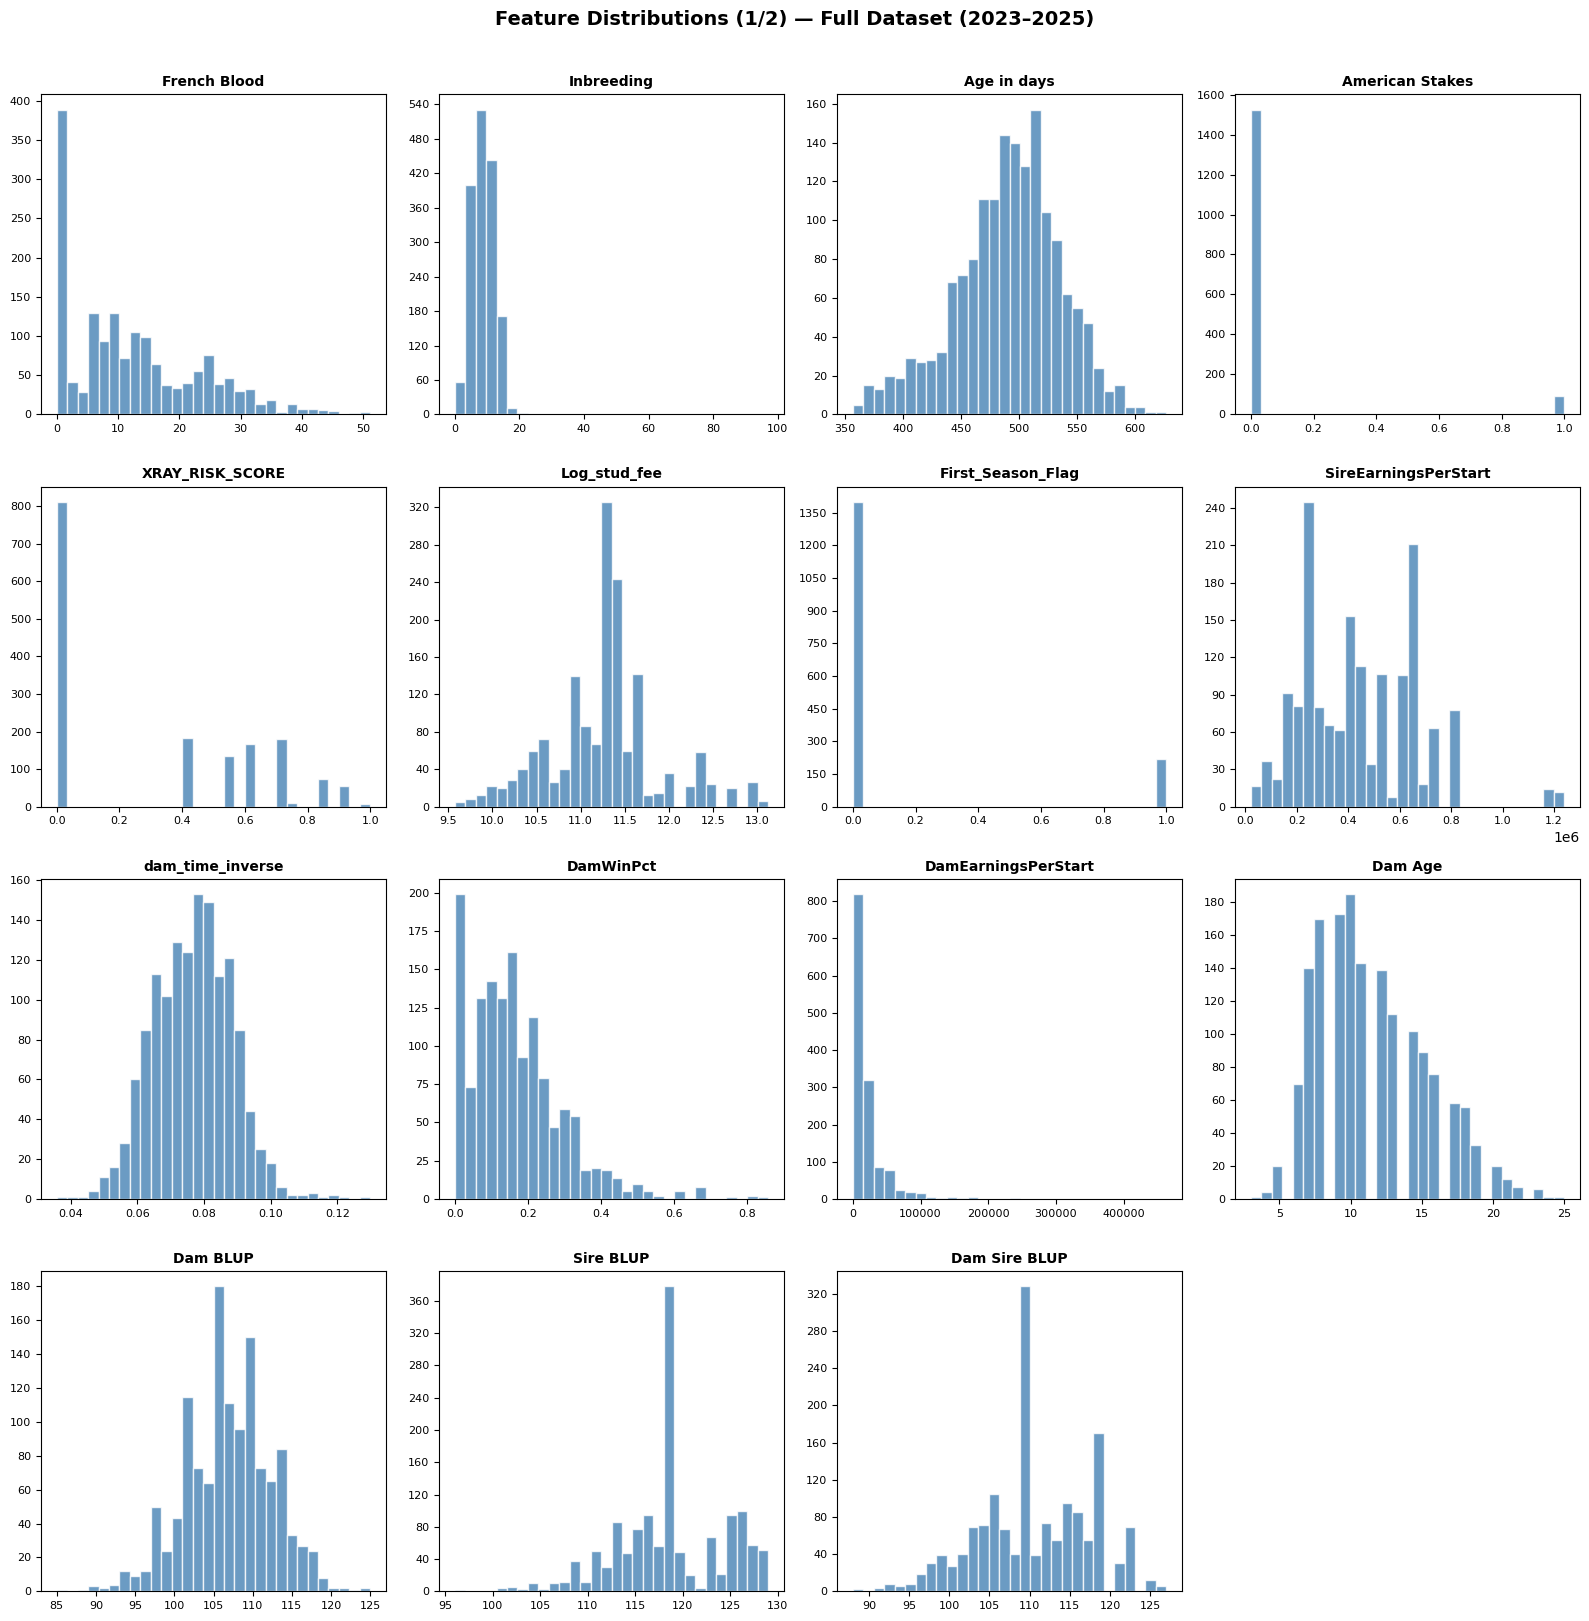

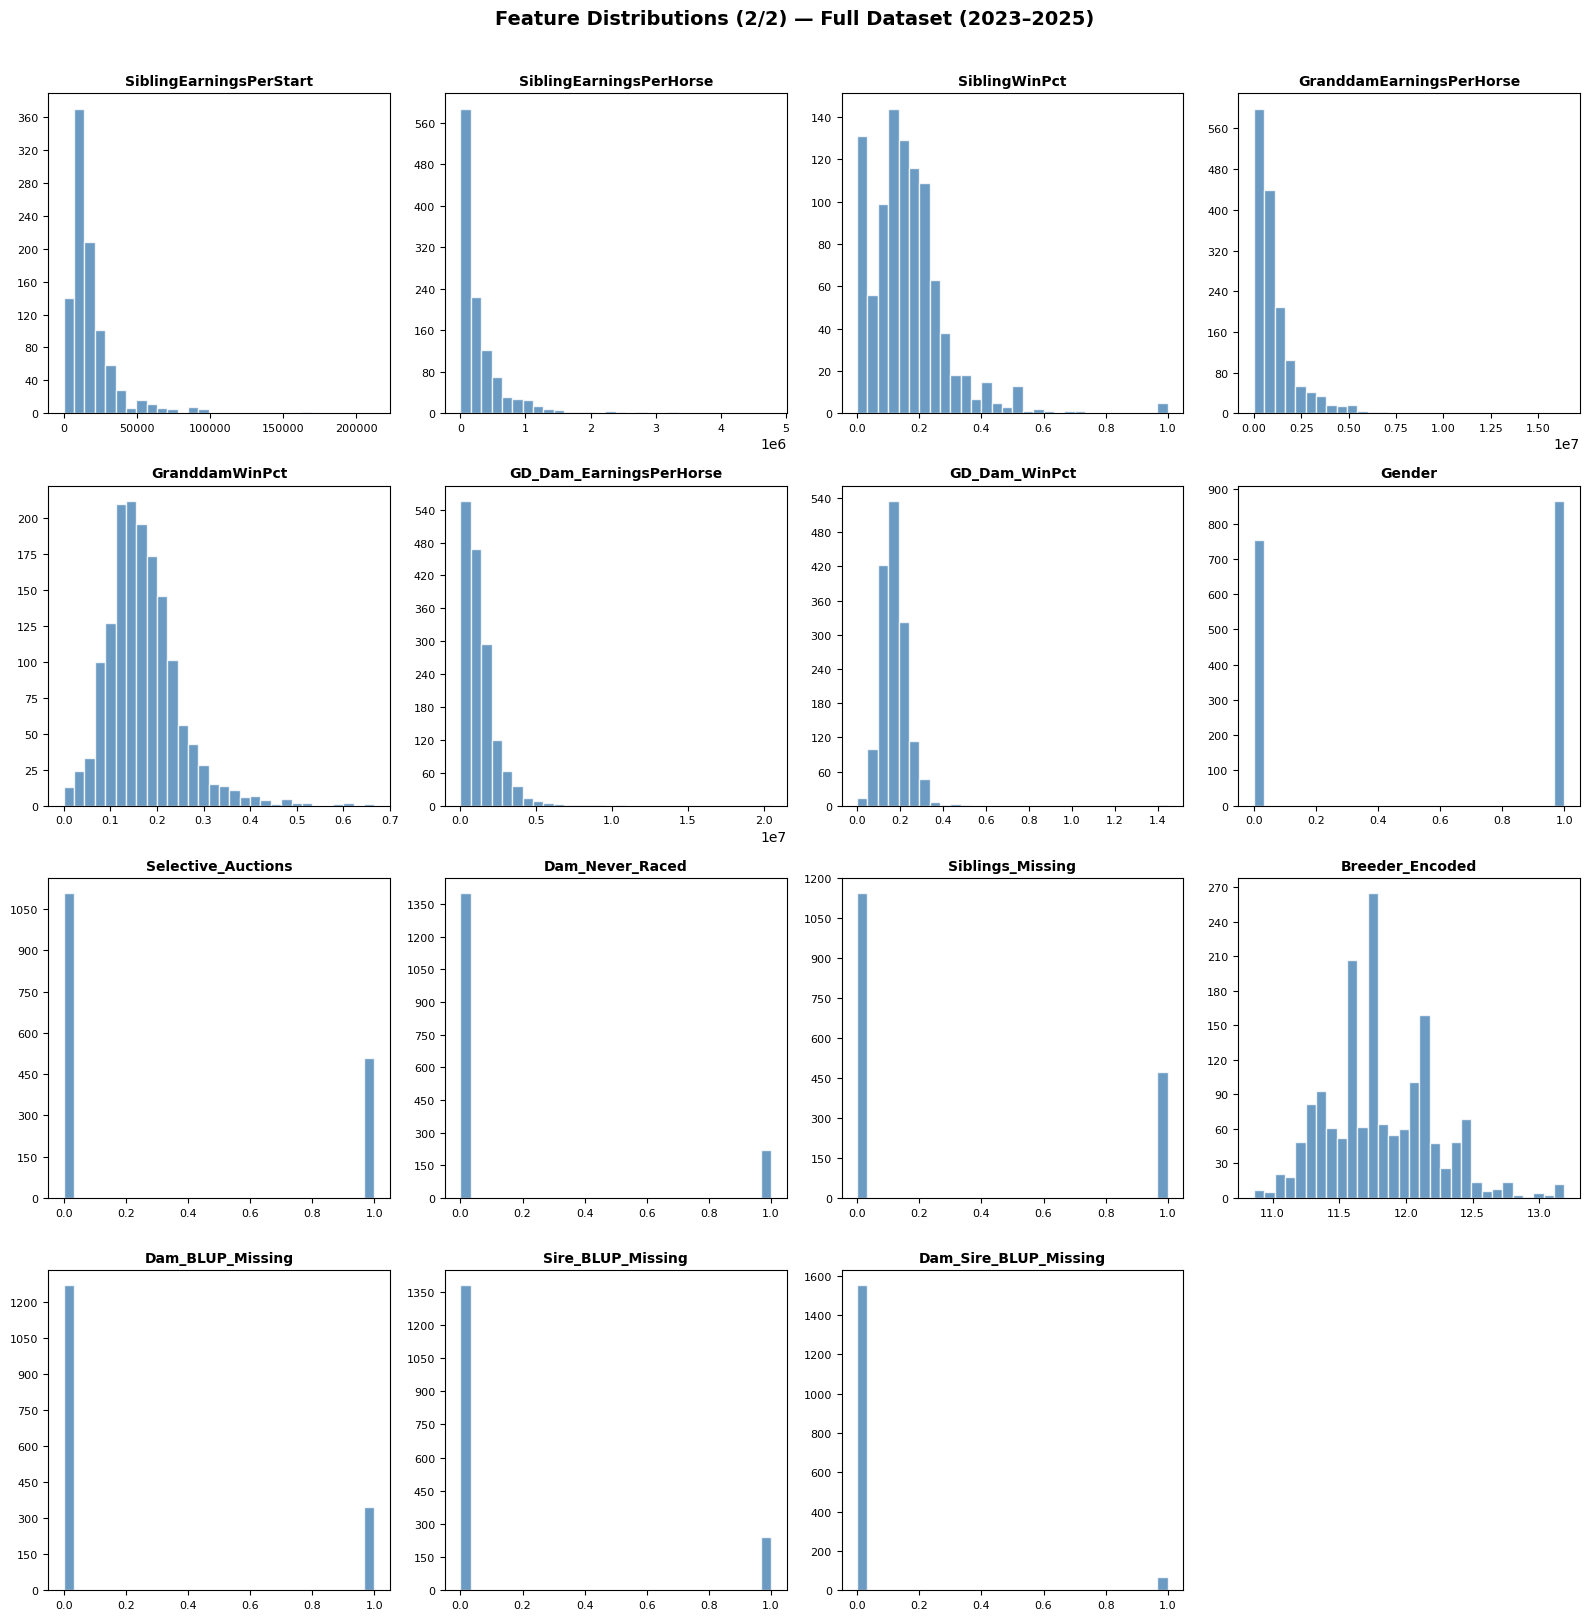

✓ Saved: feature_distributions_1.svg, feature_distributions_2.svg


In [104]:
# =========================================================
# FEATURE DISTRIBUTIONS (FULL DATASET) — PART 1 & 2
# =========================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df_full = pd.concat([df_train, df_test], ignore_index=True)

mid = 15
feature_groups = [FEATURES[:mid], FEATURES[mid:]]
titles = ["Feature Distributions (1/2)", "Feature Distributions (2/2)"]
filenames = ["feature_distributions_1.svg", "feature_distributions_2.svg"]

for group, title, fname in zip(feature_groups, titles, filenames):
    n_features = len(group)
    n_cols = 4
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, feat in enumerate(group):
        ax = axes[i]
        ax.hist(df_full[feat].dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.8)
        ax.set_title(feat, fontsize=10, fontweight="bold")
        ax.tick_params(labelsize=8)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{title} — Full Dataset (2023–2025)", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig(fname, format="svg", bbox_inches="tight")
    plt.show()

print("✓ Saved:", ", ".join(filenames))

In [105]:
# =========================================================
# MISSING VALUE DIAGNOSTICS
# =========================================================

print("="*70)
print("MISSING VALUE ANALYSIS")
print("="*70)

# ---------------------------------------------------------
# Count missing values in training data
# ---------------------------------------------------------
print("\n[MISSING VALUES IN TRAINING DATA]")
missing_counts = X_train.isna().sum()
missing_pct = (X_train.isna().sum() / len(X_train) * 100)

missing_df = pd.DataFrame({
    'Missing': missing_counts,
    'Pct': missing_pct.round(1)
}).sort_values('Missing', ascending=False)

# Show only features with missing values
missing_with_values = missing_df[missing_df['Missing'] > 0]
if len(missing_with_values) > 0:
    print(missing_with_values.to_string())
else:
    print("  No missing values detected")

# ---------------------------------------------------------
# Zero values that might represent "missing"
# ---------------------------------------------------------
print("\n[ZERO VALUES (may represent missing)]")
zero_check_cols = [col_dam_earnings, col_dam_starts, 'DamWinPct', 
                   col_siblings_raceage, 'Sibling Earnings']
zero_check_cols = [c for c in zero_check_cols if c in X_train.columns]

for col in zero_check_cols:
    n_zeros = (X_train[col] == 0).sum()
    pct_zeros = n_zeros / len(X_train) * 100
    if n_zeros > 0:
        print(f"  {col}: {n_zeros} zeros ({pct_zeros:.1f}%)")

# ---------------------------------------------------------
# Dam Never Raced Analysis
# ---------------------------------------------------------
print("\n[DAM NEVER RACED ANALYSIS]")
if 'Dam_Never_Raced' in df_train.columns:
    never_raced = df_train[df_train['Dam_Never_Raced'] == 1]
    raced = df_train[df_train['Dam_Never_Raced'] == 0]
    
    print(f"  Dam never raced: {len(never_raced)} horses ({len(never_raced)/len(df_train)*100:.1f}%)")
    print(f"  Dam raced:       {len(raced)} horses ({len(raced)/len(df_train)*100:.1f}%)")
    
    print(f"\n  Mean price (dam never raced): {never_raced[col_price].mean():,.0f} NOK")
    print(f"  Mean price (dam raced):       {raced[col_price].mean():,.0f} NOK")
    
    price_diff = raced[col_price].mean() - never_raced[col_price].mean()
    print(f"  Difference:                   {price_diff:+,.0f} NOK")

# ---------------------------------------------------------
# BLUP Missing Analysis
# ---------------------------------------------------------
print("\n[BLUP MISSING ANALYSIS]")
blup_cols = [col_dam_blup, col_sire_blup, col_dam_sire_blup]
blup_names = ["Dam BLUP", "Sire BLUP", "Dam Sire BLUP"]

for col, name in zip(blup_cols, blup_names):
    if col and col in X_train.columns:
        n_missing = X_train[col].isna().sum()
        pct_missing = n_missing / len(X_train) * 100
        print(f"  {name}: {n_missing} missing ({pct_missing:.1f}%)")
        
        if n_missing < len(X_train):
            # Price comparison
            has_blup = df_train[df_train[col].notna()]
            no_blup = df_train[df_train[col].isna()]
            if len(has_blup) > 0 and len(no_blup) > 0:
                print(f"    Mean price (has {name}): {has_blup[col_price].mean():,.0f} NOK")
                print(f"    Mean price (no {name}):  {no_blup[col_price].mean():,.0f} NOK")

# ---------------------------------------------------------
# Siblings Missing Analysis
# ---------------------------------------------------------
print("\n[SIBLINGS MISSING ANALYSIS]")
if 'Siblings_Missing' in df_train.columns:
    no_siblings = df_train[df_train['Siblings_Missing'] == 1]
    has_siblings = df_train[df_train['Siblings_Missing'] == 0]
    
    print(f"  No racing siblings: {len(no_siblings)} horses ({len(no_siblings)/len(df_train)*100:.1f}%)")
    print(f"  Has siblings:       {len(has_siblings)} horses ({len(has_siblings)/len(df_train)*100:.1f}%)")
    
    print(f"\n  Mean price (no siblings):  {no_siblings[col_price].mean():,.0f} NOK")
    print(f"  Mean price (has siblings): {has_siblings[col_price].mean():,.0f} NOK")

# ---------------------------------------------------------
# XGBoost Missing Value Handling Note
# ---------------------------------------------------------
print("\n" + "="*70)
print("XGBOOST MISSING VALUE HANDLING")
print("="*70)
print("""
XGBoost handles missing values AUTOMATICALLY:
  - At each split, learns optimal direction for missing values
  - No imputation needed - NaN is treated as informative
  - Binary indicators (Dam_Never_Raced, etc.) provide explicit signal
  
Current approach:
  ✓ NaN preserved for XGBoost to learn optimal handling
  ✓ Binary indicators added for interpretability
  ✓ Derived features (DamWinPct, etc.) are NaN when undefined
""")


X_train.to_excel("X_train_imputed.xlsx", index=True)
X_test.to_excel("X_test_imputed.xlsx", index=True)

MISSING VALUE ANALYSIS

[MISSING VALUES IN TRAINING DATA]
                          Missing   Pct
SiblingEarningsPerStart       450  40.6
SiblingWinPct                 450  40.6
SiblingEarningsPerHorse       331  29.9
Dam BLUP                      229  20.7
DamEarningsPerStart           158  14.3
Sire BLUP                     156  14.1
DamWinPct                     152  13.7
dam_time_inverse              150  13.5
GranddamWinPct                 53   4.8
GranddamEarningsPerHorse       49   4.4
Dam Sire BLUP                  46   4.2
GD_Dam_WinPct                  41   3.7
GD_Dam_EarningsPerHorse        35   3.2

[ZERO VALUES (may represent missing)]
  DamWinPct: 136 zeros (12.3%)

[DAM NEVER RACED ANALYSIS]
  Dam never raced: 152 horses (13.7%)
  Dam raced:       956 horses (86.3%)

  Mean price (dam never raced): 208,322 NOK
  Mean price (dam raced):       228,928 NOK
  Difference:                   +20,605 NOK

[BLUP MISSING ANALYSIS]
  Dam BLUP: 229 missing (20.7%)
    Mean price (ha

In [106]:
# =========================================================
# STEPWISE HYPERPARAMETER TUNING
# =========================================================

print("="*70)
print("STEPWISE HYPERPARAMETER TUNING")
print("="*70)

from sklearn.model_selection import GroupKFold, cross_val_score
import xgboost as xgb

cv = GroupKFold(n_splits=2)
groups = df_train["Year"].values

def evaluate_params(params, description=""):
    """Train model and return train/test/cv metrics"""
    model = xgb.XGBRegressor(
        **params,
        objective="reg:absoluteerror",
        #objective="reg:squarederror", 
        eval_metric="mae",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    
    # CV score (for selection)
    cv_scores = cross_val_score(model, X_train.values, y_train.values, 
                                 cv=cv, groups=groups, scoring='r2')
    cv_mean = cv_scores.mean()
    
    # Train and test scores (for reporting only)
    model.fit(X_train.values, y_train.values)
    train_r2 = r2_score(y_train, model.predict(X_train.values))
    test_r2 = r2_score(y_test, model.predict(X_test.values))
    gap = train_r2 - test_r2
    
    return train_r2, test_r2, gap, cv_mean, model

# =========================================================
# STEP 1: Find optimal max_depth (most important parameter)
# =========================================================
print("\n[STEP 1: TUNING max_depth]")
print(f"{'Depth':<8} {'Train R²':>10} {'Test R²':>10} {'Gap':>8} {'CV R²':>10}")
print(f"{'-'*8} {'-'*10} {'-'*10} {'-'*8} {'-'*10}")

base_params = {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "min_child_weight": 10,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "reg_alpha": 1,
    "reg_lambda": 5,
    "gamma": 0.1,
}

depth_results = {}
for depth in [3, 4, 5, 6, 7, 8]:
    params = {**base_params, "max_depth": depth}
    train_r2, test_r2, gap, cv_mean, _ = evaluate_params(params)
    depth_results[depth] = (train_r2, test_r2, gap, cv_mean)
    print(f"{depth:<8} {train_r2:>10.4f} {test_r2:>10.4f} {gap:>8.4f} {cv_mean:>10.4f}")

best_depth = max(depth_results.keys(), key=lambda x: depth_results[x][3])  # CHANGED: index 3 = CV R²
print(f"\n→ Best depth by CV R²: {best_depth}")

# =========================================================
# STEP 2: Tune min_child_weight (regularization)
# =========================================================
print("\n[STEP 2: TUNING min_child_weight]")
print(f"{'min_child':<12} {'Train R²':>10} {'Test R²':>10} {'Gap':>8} {'CV R²':>10}")
print(f"{'-'*12} {'-'*10} {'-'*10} {'-'*8} {'-'*10}")

base_params["max_depth"] = best_depth

mcw_results = {}
for mcw in [3, 5, 10, 15, 20, 30]:
    params = {**base_params, "min_child_weight": mcw}
    train_r2, test_r2, gap, cv_mean, _ = evaluate_params(params)
    mcw_results[mcw] = (train_r2, test_r2, gap, cv_mean)
    print(f"{mcw:<12} {train_r2:>10.4f} {test_r2:>10.4f} {gap:>8.4f} {cv_mean:>10.4f}")

best_mcw = max(mcw_results.keys(), key=lambda x: mcw_results[x][3])  # CHANGED: CV R²
print(f"\n→ Best min_child_weight by CV R²: {best_mcw}")

# =========================================================
# STEP 3: Tune gamma (split threshold)
# =========================================================
print("\n[STEP 3: TUNING gamma]")
print(f"{'Gamma':<8} {'Train R²':>10} {'Test R²':>10} {'Gap':>8} {'CV R²':>10}")
print(f"{'-'*8} {'-'*10} {'-'*10} {'-'*8} {'-'*10}")

base_params["min_child_weight"] = best_mcw

gamma_results = {}
for gamma in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]:
    params = {**base_params, "gamma": gamma}
    train_r2, test_r2, gap, cv_mean, _ = evaluate_params(params)
    gamma_results[gamma] = (train_r2, test_r2, gap, cv_mean)
    print(f"{gamma:<8} {train_r2:>10.4f} {test_r2:>10.4f} {gap:>8.4f} {cv_mean:>10.4f}")

best_gamma = max(gamma_results.keys(), key=lambda x: gamma_results[x][3])  # CHANGED: CV R²
print(f"\n→ Best gamma by CV R²: {best_gamma}")

# =========================================================
# STEP 4: Tune subsample & colsample_bytree
# =========================================================
print("\n[STEP 4: TUNING subsample & colsample_bytree]")
print(f"{'sub':>5} {'col':>5} {'Train R²':>10} {'Test R²':>10} {'Gap':>8} {'CV R²':>10}")
print(f"{'-'*5} {'-'*5} {'-'*10} {'-'*10} {'-'*8} {'-'*10}")

base_params["gamma"] = best_gamma

sample_results = {}
for sub in [0.6, 0.7, 0.8, 0.9]:
    for col in [0.5, 0.6, 0.7, 0.8]:
        params = {**base_params, "subsample": sub, "colsample_bytree": col}
        train_r2, test_r2, gap, cv_mean, _ = evaluate_params(params)
        sample_results[(sub, col)] = (train_r2, test_r2, gap, cv_mean)
        print(f"{sub:>5} {col:>5} {train_r2:>10.4f} {test_r2:>10.4f} {gap:>8.4f} {cv_mean:>10.4f}")

best_sample = max(sample_results.keys(), key=lambda x: sample_results[x][3])  # CHANGED: CV R²
print(f"\n→ Best (subsample, colsample) by CV R²: {best_sample}")

# =========================================================
# STEP 5: Tune reg_alpha & reg_lambda (L1/L2 regularization)
# =========================================================
print("\n[STEP 5: TUNING reg_alpha & reg_lambda]")
print(f"{'alpha':>6} {'lambda':>7} {'Train R²':>10} {'Test R²':>10} {'Gap':>8} {'CV R²':>10}")
print(f"{'-'*6} {'-'*7} {'-'*10} {'-'*10} {'-'*8} {'-'*10}")

base_params["subsample"] = best_sample[0]
base_params["colsample_bytree"] = best_sample[1]

reg_results = {}
for alpha in [0, 0.5, 1, 2, 5]:
    for lam in [1, 3, 5, 10]:
        params = {**base_params, "reg_alpha": alpha, "reg_lambda": lam}
        train_r2, test_r2, gap, cv_mean, _ = evaluate_params(params)
        reg_results[(alpha, lam)] = (train_r2, test_r2, gap, cv_mean)
        print(f"{alpha:>6} {lam:>7} {train_r2:>10.4f} {test_r2:>10.4f} {gap:>8.4f} {cv_mean:>10.4f}")

best_reg = max(reg_results.keys(), key=lambda x: reg_results[x][3])  # CHANGED: CV R²
print(f"\n→ Best (reg_alpha, reg_lambda) by CV R²: {best_reg}")

# =========================================================
# STEP 6: Tune learning_rate with more estimators
# =========================================================
print("\n[STEP 6: TUNING learning_rate & n_estimators]")
print(f"{'LR':>6} {'n_est':>7} {'Train R²':>10} {'Test R²':>10} {'Gap':>8} {'CV R²':>10}")
print(f"{'-'*6} {'-'*7} {'-'*10} {'-'*10} {'-'*8} {'-'*10}")

base_params["reg_alpha"] = best_reg[0]
base_params["reg_lambda"] = best_reg[1]

lr_results = {}
for lr, n_est in [(0.1, 500), (0.05, 1000), (0.03, 1500), (0.01, 3000)]:
    params = {**base_params, "learning_rate": lr, "n_estimators": n_est}
    train_r2, test_r2, gap, cv_mean, _ = evaluate_params(params)
    lr_results[(lr, n_est)] = (train_r2, test_r2, gap, cv_mean)
    print(f"{lr:>6} {n_est:>7} {train_r2:>10.4f} {test_r2:>10.4f} {gap:>8.4f} {cv_mean:>10.4f}")

best_lr = max(lr_results.keys(), key=lambda x: lr_results[x][3])  # CHANGED: CV R²
print(f"\n→ Best (learning_rate, n_estimators) by CV R²: {best_lr}")

# =========================================================
# FINAL: Compile best parameters
# =========================================================
print("\n" + "="*70)
print("FINAL BEST PARAMETERS")
print("="*70)

final_params = {
    "max_depth": best_depth,
    "min_child_weight": best_mcw,
    "gamma": best_gamma,
    "subsample": best_sample[0],
    "colsample_bytree": best_sample[1],
    "reg_alpha": best_reg[0],
    "reg_lambda": best_reg[1],
    "learning_rate": best_lr[0],
    "n_estimators": best_lr[1],
}

for param, value in final_params.items():
    print(f"  {param}: {value}")

# Final evaluation
train_r2, test_r2, gap, cv_mean, best_model = evaluate_params(final_params)
print(f"\n[FINAL MODEL PERFORMANCE]")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²:  {test_r2:.4f}")
print(f"  Gap:      {gap:.4f}")
print(f"  CV R²:    {cv_mean:.4f}")

# Check log_stud_fee importance
#log_stud_fee_imp = best_model.feature_importances_[FEATURES.index('Log_stud_fee')]
#print(f"\n  log_stud_fee importance: {log_stud_fee_imp:.4f}")

# Store for later use
best_params = final_params.copy()

STEPWISE HYPERPARAMETER TUNING

[STEP 1: TUNING max_depth]
Depth      Train R²    Test R²      Gap      CV R²
-------- ---------- ---------- -------- ----------
3            0.8325     0.4535   0.3790     0.5714
4            0.8882     0.4526   0.4356     0.5648
5            0.9226     0.4372   0.4854     0.5641
6            0.9384     0.4495   0.4889     0.5582
7            0.9475     0.4465   0.5010     0.5616
8            0.9563     0.4512   0.5051     0.5562

→ Best depth by CV R²: 3

[STEP 2: TUNING min_child_weight]
min_child      Train R²    Test R²      Gap      CV R²
------------ ---------- ---------- -------- ----------
3                0.8426     0.4602   0.3824     0.5633
5                0.8452     0.4539   0.3913     0.5643
10               0.8325     0.4535   0.3790     0.5714
15               0.8300     0.4471   0.3829     0.5713
20               0.8200     0.4469   0.3731     0.5628
30               0.8152     0.4452   0.3699     0.5712

→ Best min_child_weight by CV R

In [107]:
# =========================================================
# FINAL MODEL TRAINING & EVALUATION
# =========================================================

print("="*70)
print("FINAL MODEL TRAINING & EVALUATION")
print("="*70)

from sklearn.model_selection import cross_val_predict, GroupKFold

# ---------------------------------------------------------
# Year-based split for early stopping
# ---------------------------------------------------------
years_train = df_train["Year"].values
tr_mask = (years_train == 2023)
val_mask = (years_train == 2024)

X_tr = X_train.values[tr_mask]
y_tr = y_train.values[tr_mask]
X_val = X_train.values[val_mask]
y_val = y_train.values[val_mask]

# ---------------------------------------------------------
# Train final model 
# --------------------------------------------
final_params = best_params.copy()
#final_params["n_estimators"] = max(final_params.get("n_estimators", 0), 4000)

best_model = xgb.XGBRegressor(
    **final_params,
    objective="reg:absoluteerror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
 #   early_stopping_rounds=500,
)

best_model.fit(X_train.values, y_train.values)

print("\n[TRAINING COMPLETE]")
print(f"  Trees used: {best_model.n_estimators}")
print(f"  Parameters:")
for param, value in final_params.items():
    print(f"    {param}: {value}")


#best_model.fit(
#    X_tr, y_tr,
#    eval_set=[(X_val, y_val)],
#    verbose=False
#)


# ---------------------------------------------------------
# Predictions (log scale)
# ---------------------------------------------------------
pred_train_tuned = best_model.predict(X_train.values)
pred_test_tuned = best_model.predict(X_test.values)

# ---------------------------------------------------------
# LOG SCALE METRICS
# ---------------------------------------------------------
train_r2_log = r2_score(y_train, pred_train_tuned)
test_r2_log = r2_score(y_test, pred_test_tuned)
rmse_log = np.sqrt(mean_squared_error(y_test, pred_test_tuned))
mae_log = mean_absolute_error(y_test, pred_test_tuned)


print(f"\n[LOG SCALE METRICS]")
print(f"  Train R²:  {train_r2_log:.4f}")
print(f"  Test R²:   {test_r2_log:.4f}")
print(f"  RMSE:      {rmse_log:.4f}")
print(f"  MAE:       {mae_log:.4f}")

gap = train_r2_log - test_r2_log
print(f"\n  Train-Test Gap: {gap:.3f}", end="")
print("  ⚠️ Overfitting suspected" if gap > 0.15 else "  ✓ Acceptable")

# =========================================================
# OUT-OF-FOLD SIGMA² ESTIMATION
# =========================================================

print("\n" + "="*70)
print("OUT-OF-FOLD SIGMA² ESTIMATION")
print("="*70)

# Create model with tuned parameters
oof_model = xgb.XGBRegressor(
    **best_params,
    objective="reg:absoluteerror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

# Get OOF predictions using GroupKFold (same as tuning)
cv = GroupKFold(n_splits=2)  # or 5 for more folds
groups = df_train["Year"].values

oof_predictions = cross_val_predict(
    oof_model, 
    X_train.values, 
    y_train.values, 
    cv=cv, 
    groups=groups
)

# Calculate OOF residuals and sigma²
oof_residuals = y_train.values - oof_predictions
sigma2_oof = np.var(oof_residuals)

# Compare all three (now pred_train_tuned and pred_test_tuned exist!)
sigma2_train = np.var(y_train.values - pred_train_tuned)
sigma2_test = np.var(y_test.values - pred_test_tuned)

print(f"\n[SIGMA² COMPARISON]")
print(f"  {'Method':<20} {'σ²':>10} {'Correction':>12}")
print(f"  {'-'*20} {'-'*10} {'-'*12}")
print(f"  {'Training (in-sample)':<20} {sigma2_train:>10.4f} {np.exp(sigma2_train/2):>12.4f}")
print(f"  {'OOF (out-of-fold)':<20} {sigma2_oof:>10.4f} {np.exp(sigma2_oof/2):>12.4f}")
print(f"  {'Test (diagnostic)':<20} {sigma2_test:>10.4f} {np.exp(sigma2_test/2):>12.4f}")

print(f"\n[RECOMMENDATION]")
if sigma2_oof > sigma2_train * 1.5:
    print(f"  OOF σ² is {sigma2_oof/sigma2_train:.1f}x larger than training σ²")
    print(f"  → Use OOF σ² = {sigma2_oof:.4f} for more realistic correction")
else:
    print(f"  OOF and training σ² are similar")
    print(f"  → Training σ² is acceptable")

# ---------------------------------------------------------
# PRICE SCALE CONVERSION
# Choose ONE method by uncommenting the appropriate section
# ---------------------------------------------------------

# Actual prices (always needed)
y_train_price = np.exp(y_train.values)
y_test_price = np.exp(y_test.values)

#pred_train_price_tuned = np.exp(pred_train_tuned)
#pred_test_price_tuned = np.exp(pred_test_tuned)
#conversion_method = "Median (no correction)"
#correction_factor = 1.0

# === METHOD 2: Sigma²/2 correction (parametric mean estimate) ===
#sigma2 = np.var(y_train.values - pred_train_tuned)
#pred_train_price_tuned = np.exp(pred_train_tuned + sigma2/2)
#pred_test_price_tuned = np.exp(pred_test_tuned + sigma2/2)
#conversion_method = "Sigma²/2 correction"
#correction_factor = np.exp(sigma2/2)


# === METHOD 2b: Sigma²/2 correction using OOF estimate ===
sigma2 = sigma2_oof  # Use OOF instead of training
pred_train_price_tuned = np.exp(pred_train_tuned + sigma2/2)
pred_test_price_tuned = np.exp(pred_test_tuned + sigma2/2)
conversion_method = f"Sigma²/2 correction (OOF σ²={sigma2:.4f})"
correction_factor = np.exp(sigma2/2)

print(f"\n[PRICE SCALE CONVERSION]")
print(f"  Method: {conversion_method}")
print(f"  Correction factor: {correction_factor:.4f}")

# === METHOD 3: Smearing (Duan's non-parametric mean estimate) ===
#train_residuals = y_train.values - pred_train_tuned
#smearing_factor = np.mean(np.exp(train_residuals))
#pred_train_price_tuned = np.exp(pred_train_tuned) * smearing_factor
#pred_test_price_tuned = np.exp(pred_test_tuned) * smearing_factor
#conversion_method = "Smearing (Duan's estimator)"
#correction_factor = smearing_factor

# ---------------------------------------------------------
# PRICE SCALE METRICS
# ---------------------------------------------------------
test_r2_price = r2_score(y_test_price, pred_test_price_tuned)
rmse_price = np.sqrt(mean_squared_error(y_test_price, pred_test_price_tuned))
mae_price = mean_absolute_error(y_test_price, pred_test_price_tuned)
mean_error = np.mean(pred_test_price_tuned - y_test_price)
median_error = np.median(pred_test_price_tuned - y_test_price)
mape_price = np.mean(np.abs((y_test_price - pred_test_price_tuned) / y_test_price)) * 100
mdape_price = np.median(np.abs((y_test_price - pred_test_price_tuned) / y_test_price)) * 100

print(f"\n[PRICE SCALE METRICS (NOK)]")
print(f"  Test R²:       {test_r2_price:.4f}")
print(f"  RMSE:          {rmse_price:,.0f}")
print(f"  MAE:           {mae_price:,.0f}")
print(f"  Mean Error:    {mean_error:+,.0f}")
print(f"  Median Error:  {median_error:+,.0f}")
print(f"  MAPE:          {mape_price:.1f}%")
print(f"  MdAPE:         {mdape_price:.1f}%")

# ---------------------------------------------------------
# Convert to numpy arrays for later cells
# ---------------------------------------------------------
y_test_price_array = y_test_price


FINAL MODEL TRAINING & EVALUATION

[TRAINING COMPLETE]
  Trees used: 3000
  Parameters:
    max_depth: 3
    min_child_weight: 10
    gamma: 0.5
    subsample: 0.8
    colsample_bytree: 0.8
    reg_alpha: 1
    reg_lambda: 5
    learning_rate: 0.01
    n_estimators: 3000

[LOG SCALE METRICS]
  Train R²:  0.8115
  Test R²:   0.4612
  RMSE:      0.7318
  MAE:       0.5983

  Train-Test Gap: 0.350  ⚠️ Overfitting suspected

OUT-OF-FOLD SIGMA² ESTIMATION

[SIGMA² COMPARISON]
  Method                       σ²   Correction
  -------------------- ---------- ------------
  Training (in-sample)     0.1913       1.1004
  OOF (out-of-fold)        0.4245       1.2365
  Test (diagnostic)        0.5299       1.3034

[RECOMMENDATION]
  OOF σ² is 2.2x larger than training σ²
  → Use OOF σ² = 0.4245 for more realistic correction

[PRICE SCALE CONVERSION]
  Method: Sigma²/2 correction (OOF σ²=0.4245)
  Correction factor: 1.2365

[PRICE SCALE METRICS (NOK)]
  Test R²:       0.3767
  RMSE:          253,16

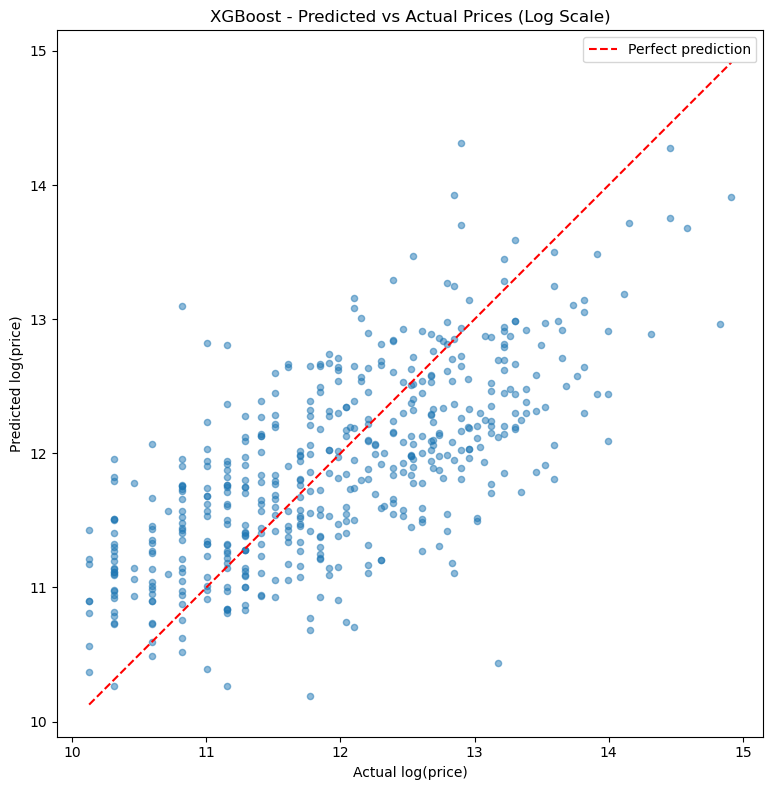

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot: Predicted vs Actual (Log Scale)
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, pred_test_tuned, alpha=0.5, s=20)

# Perfect prediction line
min_val = min(y_test.min(), pred_test_tuned.min())
max_val = max(y_test.max(), pred_test_tuned.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual log(price)')
ax.set_ylabel('Predicted log(price)')
ax.set_title('XGBoost - Predicted vs Actual Prices (Log Scale)')
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('XGB_predictions_vs_actuals.svg', dpi=150, bbox_inches='tight')
plt.show()

RESIDUAL ANALYSIS

[RESIDUAL STATISTICS - LOG SCALE]
  Mean:     -0.0744
  Median:    -0.0789
  Std:      0.7280
  Skewness: -0.1001
  Kurtosis: -0.1937

[RESIDUAL STATISTICS - PRICE SCALE]
  Mean:     -23,016 NOK
  Median:   +17,135 NOK
  Std:      252,121 NOK
  Skewness: -1.8968
  Kurtosis: 19.6418

[NORMALITY TESTS - LOG SCALE]
  H0: Residuals are normally distributed
  Reject H0 if p < 0.05


[INTERPRETATION]
  Skewness (-0.10): Approximately symmetric ✓
  Kurtosis (-0.19): Near normal tails ✓

[BIAS ANALYSIS]
  Mean Error:   -23,016 NOK
  Median Error: +17,135 NOK
  Gap:          -40,150 NOK

  → Systematic bias detected


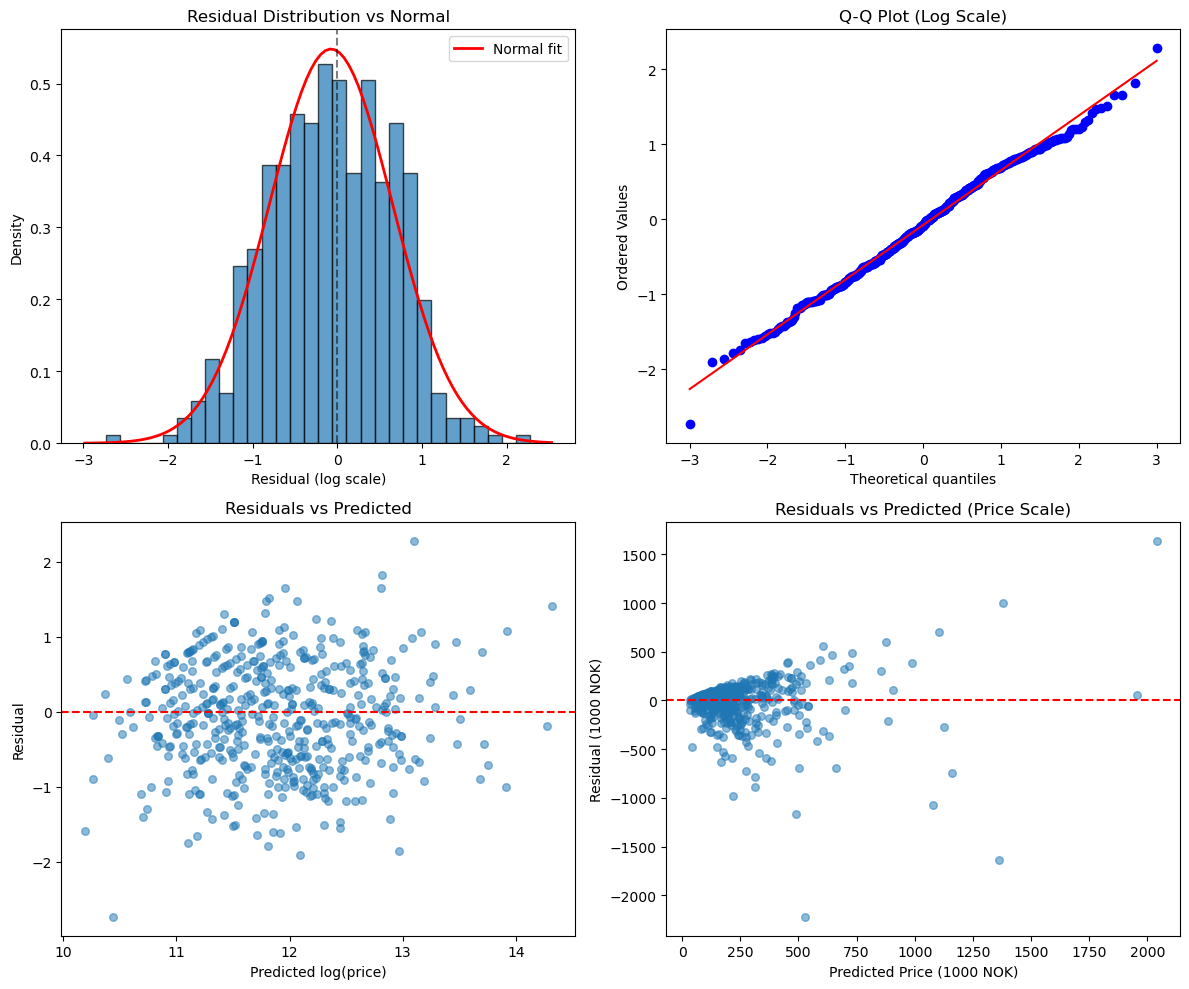


✓ Saved: XGboost_residual_analysis.svg


In [137]:
# =========================================================
# RESIDUAL ANALYSIS AND NORMALITY TESTS
# =========================================================
from scipy import stats

print("="*70)
print("RESIDUAL ANALYSIS")
print("="*70)



# Calculate residuals
residuals_log = pred_test_tuned -  y_test.values 
residuals_price =  pred_test_price_tuned-  y_test_price 

# ---------------------------------------------------------
# Descriptive statistics
# ---------------------------------------------------------
print(f"\n[RESIDUAL STATISTICS - LOG SCALE]")
print(f"  Mean:     {np.mean(residuals_log):.4f}")
print(f"  Median:    {np.median(residuals_log):.4f}")
print(f"  Std:      {np.std(residuals_log):.4f}")
print(f"  Skewness: {stats.skew(residuals_log):.4f}")
print(f"  Kurtosis: {stats.kurtosis(residuals_log):.4f}")

print(f"\n[RESIDUAL STATISTICS - PRICE SCALE]")
print(f"  Mean:     {np.mean(residuals_price):+,.0f} NOK")
print(f"  Median:   {np.median(residuals_price):+,.0f} NOK")
print(f"  Std:      {np.std(residuals_price):,.0f} NOK")
print(f"  Skewness: {stats.skew(residuals_price):.4f}")
print(f"  Kurtosis: {stats.kurtosis(residuals_price):.4f}")

# ---------------------------------------------------------
# Normality tests (on log scale residuals)
# ---------------------------------------------------------
print(f"\n[NORMALITY TESTS - LOG SCALE]")
print(f"  H0: Residuals are normally distributed")
print(f"  Reject H0 if p < 0.05\n")

# Shapiro-Wilk
#if len(residuals_log) <= 5000:
#    stat_sw, p_sw = stats.shapiro(residuals_log)
#    result_sw = "Normal ✓" if p_sw > 0.05 else "Not Normal ✗"
#    print(f"  Shapiro-Wilk:      W = {stat_sw:.4f}, p = {p_sw:.4f}  → {result_sw}")

# Jarque-Bera
#stat_jb, p_jb = stats.jarque_bera(residuals_log)
#result_jb = "Normal ✓" if p_jb > 0.05 else "Not Normal ✗"
#print(f"  Jarque-Bera:       JB = {stat_jb:.4f}, p = {p_jb:.4f}  → {result_jb}")


# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------
print(f"\n[INTERPRETATION]")
skewness = stats.skew(residuals_log)
kurtosis = stats.kurtosis(residuals_log)

if abs(skewness) < 0.5:
    print(f"  Skewness ({skewness:.2f}): Approximately symmetric ✓")
elif skewness > 0:
    print(f"  Skewness ({skewness:.2f}): Right-skewed (underpredicts expensive horses)")
else:
    print(f"  Skewness ({skewness:.2f}): Left-skewed (overpredicts expensive horses)")

if abs(kurtosis) < 1:
    print(f"  Kurtosis ({kurtosis:.2f}): Near normal tails ✓")
elif kurtosis > 0:
    print(f"  Kurtosis ({kurtosis:.2f}): Heavy tails (more outliers than normal)")
else:
    print(f"  Kurtosis ({kurtosis:.2f}): Light tails (fewer outliers than normal)")

# ---------------------------------------------------------
# Bias Analysis
# ---------------------------------------------------------
print(f"\n[BIAS ANALYSIS]")
print(f"  Mean Error:   {np.mean(residuals_price):+,.0f} NOK")
print(f"  Median Error: {np.median(residuals_price):+,.0f} NOK")
print(f"  Gap:          {np.mean(residuals_price) - np.median(residuals_price):+,.0f} NOK")

if abs(np.mean(residuals_price)) > 2 * abs(np.median(residuals_price)):
    print(f"\n  → Mean >> Median: Outliers driving the bias")
    print(f"  → Model is well-calibrated for typical horses")
else:
    print(f"\n  → Systematic bias detected")

# ---------------------------------------------------------
# Visual diagnostics
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) Histogram with normal overlay
ax1 = axes[0, 0]
ax1.hist(residuals_log, bins=30, density=True, alpha=0.7, edgecolor='black')
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
ax1.plot(x, stats.norm.pdf(x, np.mean(residuals_log), np.std(residuals_log)), 
         'r-', linewidth=2, label='Normal fit')
ax1.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Residual (log scale)')
ax1.set_ylabel('Density')
ax1.set_title('Residual Distribution vs Normal')
ax1.legend()

# 2) Q-Q plot
ax2 = axes[0, 1]
stats.probplot(residuals_log, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Log Scale)')

# 3) Residuals vs Predicted
ax3 = axes[1, 0]
ax3.scatter(pred_test_tuned, residuals_log, alpha=0.5, s=30)
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Predicted log(price)')
ax3.set_ylabel('Residual')
ax3.set_title('Residuals vs Predicted')

# 4) Price scale residuals
#ax4 = axes[1, 1]
#ax4.hist(residuals_price/1000, bins=30, alpha=0.7, edgecolor='black')
#ax4.axvline(x=0, color='black', linestyle='--')
#ax4.axvline(x=np.mean(residuals_price)/1000, color='black', linestyle='--', 
#            label=f'Mean: {np.mean(residuals_price)/1000:+.0f}k')
#ax4.axvline(x=np.median(residuals_price)/1000, color='red', linestyle='--', 
#            label=f'Median: {np.median(residuals_price)/1000:+.0f}k')
#ax4.set_xlabel('Residual (1000 NOK)')
#ax4.set_ylabel('Count')
#ax4.set_title('Residual Distribution (Price Scale)')
#ax4.legend()

#plt.tight_layout()
#plt.savefig('XGB_residual_normality.svg', dpi=150, bbox_inches='tight')
#plt.show()

# Residuals vs Fitted (price scale)
ax4 = axes[1, 1]
ax4.scatter(pred_test_price_tuned/1000, residuals_price/1000, alpha=0.5, s=30)
ax4.axhline(y=0, color='r', linestyle='--')
ax4.set_xlabel('Predicted Price (1000 NOK)')
ax4.set_ylabel('Residual (1000 NOK)')
ax4.set_title('Residuals vs Predicted (Price Scale)')

plt.tight_layout()
plt.savefig('XGBoost_residual_analysis.svg', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: XGboost_residual_analysis.svg")



In [110]:
# =========================================================
# PREDICTIONS 
# =========================================================

print("="*70)
print("PREDICTIONS AND MODEL COMPARISON")
print("="*70)

# ---------------------------------------------------------
# Create results dataframe (use already calculated predictions)
# ---------------------------------------------------------
pred_test_log = pred_test_tuned
pred_test_price = pred_test_price_tuned
actual_test_price = y_test_price_array

results_df = pd.DataFrame({
    'ID': df_test['ID'].values if 'ID' in df_test.columns else range(len(y_test)),
    'Actual_LogPrice': y_test.values,
    'Predicted_LogPrice': pred_test_log,
    'Residual_Log': y_test.values - pred_test_log,
    'APE_Log': np.abs((y_test.values - pred_test_log) / y_test.values) * 100,
    'Actual_Price': actual_test_price,
    'Predicted_Price': pred_test_price,
    'Error_Price': actual_test_price - pred_test_price,
    'APE_Price': np.abs((actual_test_price - pred_test_price) / actual_test_price) * 100,
})

# ---------------------------------------------------------
# MAPE by price tier
# ---------------------------------------------------------
print("\n[MAPE BY PRICE TIER]")
results_df['Price_Tier'] = pd.cut(results_df['Actual_Price'], 
                                   bins=[0, 100000, 200000, 400000, np.inf],
                                   labels=['<100k', '100-200k', '200-400k', '>400k'])

tier_summary = results_df.groupby('Price_Tier').agg({
    'APE_Price': ['mean', 'median', 'count']
}).round(1)
tier_summary.columns = ['MAPE', 'MdAPE', 'Count']
print(tier_summary)


# ---------------------------------------------------------
# Export predictions
# ---------------------------------------------------------
results_df.to_excel("XGB_Predictions_2025.xlsx", index=False)
print(f"\n✓ Exported to XGB_Predictions_2025.xlsx")



PREDICTIONS AND MODEL COMPARISON

[MAPE BY PRICE TIER]
             MAPE  MdAPE  Count
Price_Tier                     
<100k       132.8  110.7    177
100-200k     64.7   39.4    118
200-400k     43.3   33.6    114
>400k        50.5   49.7    101

✓ Exported to XGB_Predictions_2025.xlsx


TOP-DECILE ANALYSIS

[TOP-DECILE THRESHOLD]
  Test set:  550,000 NOK (90th percentile)

[TOP-DECILE CLASSIFICATION METRICS - Test Set]
  Precision: 0.556  (Of predicted top-10%, how many actually are?)
  Recall:    0.242  (Of actual top-10%, how many did we catch?)
  F1-Score:  0.337

[TOP-DECILE CONFUSION MATRIX - Test Set]

                    Predicted
                 Not Top-10%  Top-10%
Actual Not Top           436        12
Actual Top-10%            47        15

  True Positives (TP):    15  (Correctly identified as top-10%)
  False Positives (FP):   12  (Predicted top-10% but not)
  True Negatives (TN):   436  (Correctly identified as not top-10%)
  False Negatives (FN):   47  (Missed actual top-10%)

[HIT RATE ANALYSIS]
  (If you bid on predicted top-10%, what do you get?)

  Strategy: Bid on top 62 horses (by predicted price)
  Result:   30 out of 62 are actually top-10%
  Hit Rate: 48.4%

  Horses we'd bid on:
    Avg predicted price:      673,318 NOK
    Avg actual price: 

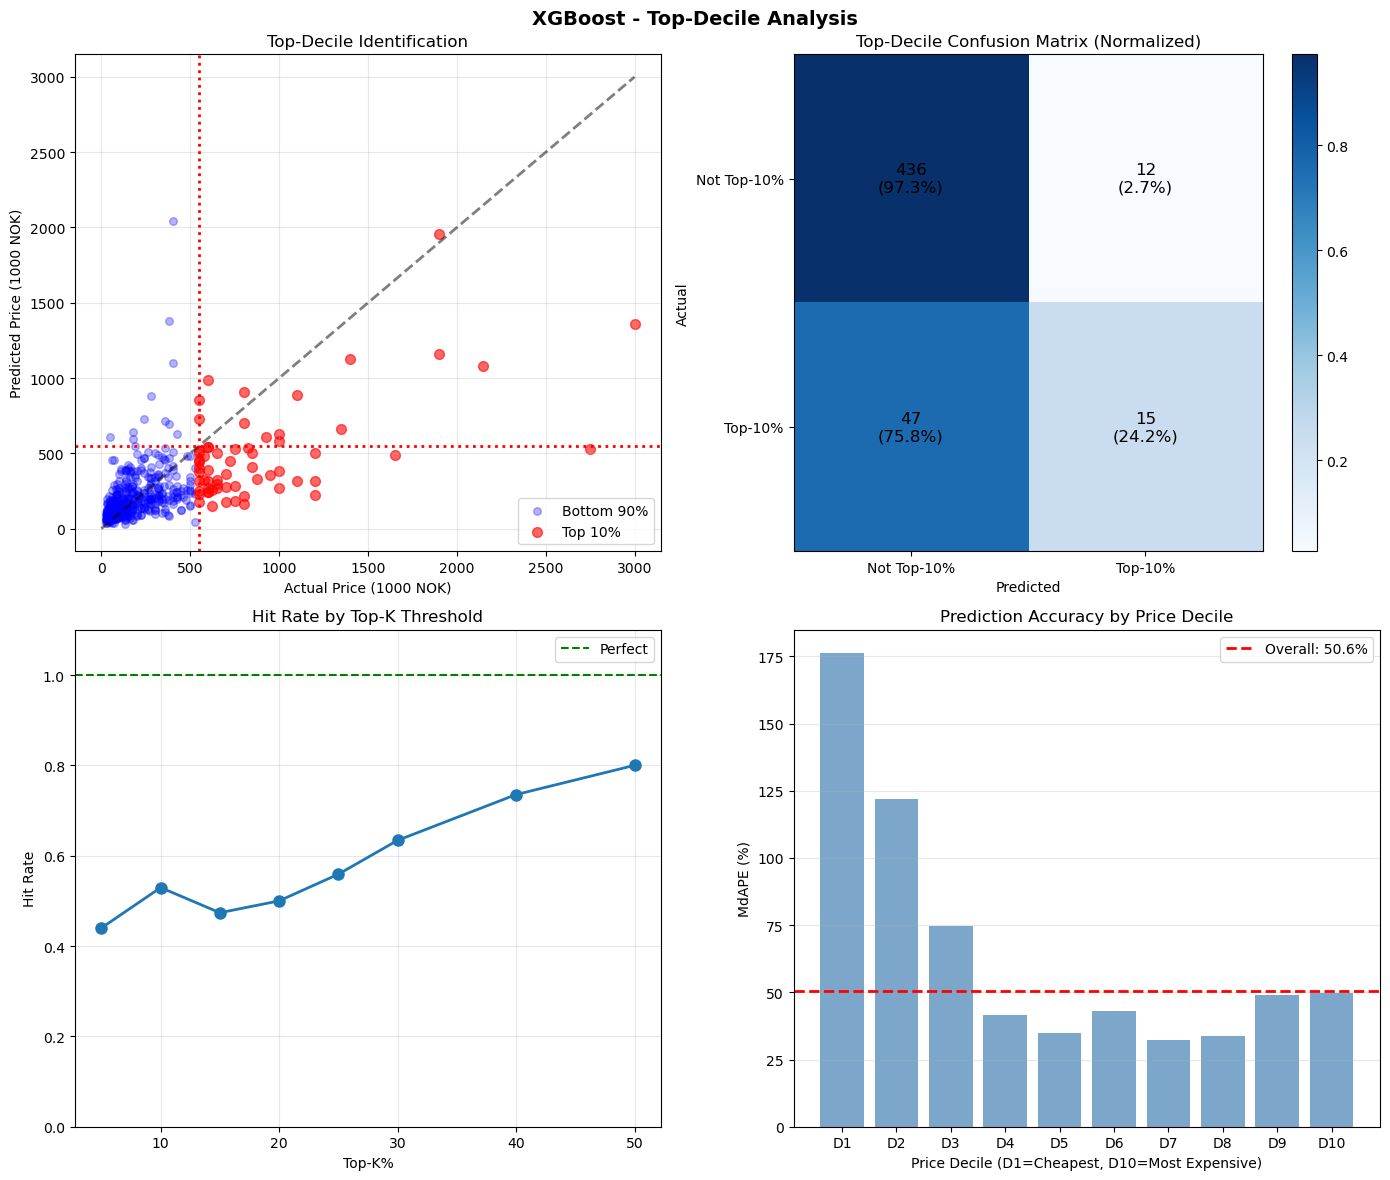

✓ Saved: xgb_top_decile_analysis.png


In [111]:
# =========================================================
# TOP-DECILE ANALYSIS
# =========================================================

print("="*70)
print("TOP-DECILE ANALYSIS")
print("="*70)

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from scipy.stats import spearmanr, kendalltau

# ---------------------------------------------------------
# Convert to numpy arrays FIRST (use throughout)
# ---------------------------------------------------------
y_test_price_array = y_test_price.values if hasattr(y_test_price, 'values') else y_test_price

# ---------------------------------------------------------
# 1. Define top-decile threshold
# ---------------------------------------------------------
top_decile_threshold_test = np.percentile(y_test_price_array, 90)

print(f"\n[TOP-DECILE THRESHOLD]")
print(f"  Test set:  {top_decile_threshold_test:,.0f} NOK (90th percentile)")

# ---------------------------------------------------------
# 2. Classify horses
# ---------------------------------------------------------
actual_top_decile_test = y_test_price_array >= top_decile_threshold_test
pred_top_decile_test = pred_test_price_tuned >= top_decile_threshold_test

# ---------------------------------------------------------
# 3. Classification metrics
# ---------------------------------------------------------
precision_test = precision_score(actual_top_decile_test, pred_top_decile_test)
recall_test = recall_score(actual_top_decile_test, pred_top_decile_test)
f1_test = f1_score(actual_top_decile_test, pred_top_decile_test)

print(f"\n[TOP-DECILE CLASSIFICATION METRICS - Test Set]")
print(f"  Precision: {precision_test:.3f}  (Of predicted top-10%, how many actually are?)")
print(f"  Recall:    {recall_test:.3f}  (Of actual top-10%, how many did we catch?)")
print(f"  F1-Score:  {f1_test:.3f}")

# ---------------------------------------------------------
# 4. Confusion Matrix
# ---------------------------------------------------------
print(f"\n[TOP-DECILE CONFUSION MATRIX - Test Set]")

cm = confusion_matrix(actual_top_decile_test, pred_top_decile_test)

print(f"\n                    Predicted")
print(f"                 Not Top-10%  Top-10%")
print(f"Actual Not Top   {cm[0,0]:>11}  {cm[0,1]:>8}")
print(f"Actual Top-10%   {cm[1,0]:>11}  {cm[1,1]:>8}")

tn, fp, fn, tp = cm.ravel()
print(f"\n  True Positives (TP):  {tp:>4}  (Correctly identified as top-10%)")
print(f"  False Positives (FP): {fp:>4}  (Predicted top-10% but not)")
print(f"  True Negatives (TN):  {tn:>4}  (Correctly identified as not top-10%)")
print(f"  False Negatives (FN): {fn:>4}  (Missed actual top-10%)")

# ---------------------------------------------------------
# 5. Hit Rate Analysis
# ---------------------------------------------------------
print(f"\n[HIT RATE ANALYSIS]")
print("  (If you bid on predicted top-10%, what do you get?)")

n_top = actual_top_decile_test.sum()
test_indices = np.argsort(pred_test_price_tuned)[::-1]
top_n_predicted = test_indices[:n_top]

hits = actual_top_decile_test[top_n_predicted].sum()
hit_rate = hits / n_top

print(f"\n  Strategy: Bid on top {n_top} horses (by predicted price)")
print(f"  Result:   {hits} out of {n_top} are actually top-10%")
print(f"  Hit Rate: {hit_rate:.1%}")

avg_actual_price_bid = y_test_price_array[top_n_predicted].mean()
avg_pred_price_bid = pred_test_price_tuned[top_n_predicted].mean()

print(f"\n  Horses we'd bid on:")
print(f"    Avg predicted price: {avg_pred_price_bid:>12,.0f} NOK")
print(f"    Avg actual price:    {avg_actual_price_bid:>12,.0f} NOK")
print(f"    Difference:          {avg_actual_price_bid - avg_pred_price_bid:>+12,.0f} NOK")

# ---------------------------------------------------------
# 6. Rank Correlation
# ---------------------------------------------------------
print(f"\n[RANK CORRELATION]")
print("  (How well does model rank horses from cheap to expensive?)")

spearman_corr, spearman_p = spearmanr(y_test_price_array, pred_test_price_tuned)
kendall_corr, kendall_p = kendalltau(y_test_price_array, pred_test_price_tuned)

print(f"\n  Spearman Correlation: {spearman_corr:.4f} (p={spearman_p:.4e})")
print(f"  Kendall Tau:          {kendall_corr:.4f} (p={kendall_p:.4e})")

if spearman_corr > 0.7:
    print(f"  ✓ Excellent ranking ability")
elif spearman_corr > 0.5:
    print(f"  ~ Good ranking ability")
else:
    print(f"  ⚠ Moderate ranking ability")

# ---------------------------------------------------------
# 7a. Top-K Accuracy
# ---------------------------------------------------------
print(f"\n[TOP-K ACCURACY FOR DIFFERENT K VALUES]")
print(f"{'Top-K':<10} {'Actual in K':<15} {'Hit Rate':<12} {'Precision'}")
print(f"{'-'*10} {'-'*15} {'-'*12} {'-'*12}")

for k_pct in [5, 10, 15, 20, 25]:
    k = int(len(y_test_price_array) * k_pct / 100)
    top_k_indices = np.argsort(pred_test_price_tuned)[::-1][:k]
    threshold_k = np.percentile(y_test_price_array, 100 - k_pct)
    actual_top_k = y_test_price_array >= threshold_k
    hits_k = actual_top_k[top_k_indices].sum()
    hit_rate_k = hits_k / k
    print(f"Top-{k_pct:>2}%    {hits_k:>5}/{k:<7}    {hit_rate_k:>11.1%}    {hit_rate_k:.3f}")

# ---------------------------------------------------------
# 7b. Bottom-K Accuracy (Identifying Cheap Horses)
# ---------------------------------------------------------
print(f"\n[BOTTOM-K ACCURACY FOR DIFFERENT K VALUES]")
print(f"{'Bottom-K':<12} {'Actual in K':<15} {'Hit Rate':<12} {'Precision'}")
print(f"{'-'*12} {'-'*15} {'-'*12} {'-'*12}")

for k_pct in [5, 10, 15, 20, 25]:
    k = int(len(y_test_price_array) * k_pct / 100)
    bottom_k_indices = np.argsort(pred_test_price_tuned)[:k]
    threshold_k = np.percentile(y_test_price_array, k_pct)
    actual_bottom_k = y_test_price_array <= threshold_k
    hits_k = actual_bottom_k[bottom_k_indices].sum()
    hit_rate_k = hits_k / k
    print(f"Bottom-{k_pct:>2}%    {hits_k:>5}/{k:<7}    {hit_rate_k:>11.1%}    {hit_rate_k:.3f}")

# ---------------------------------------------------------
# 8. Visualization
# ---------------------------------------------------------
print(f"\n[CREATING VISUALIZATIONS]")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Scatter with top-decile highlighted
ax1 = axes[0, 0]
mask_regular = ~actual_top_decile_test
ax1.scatter(y_test_price_array[mask_regular]/1000, 
            pred_test_price_tuned[mask_regular]/1000,
            alpha=0.3, s=30, label='Bottom 90%', color='blue')
ax1.scatter(y_test_price_array[actual_top_decile_test]/1000,
            pred_test_price_tuned[actual_top_decile_test]/1000,
            alpha=0.6, s=50, label='Top 10%', color='red')
max_price = y_test_price_array.max() / 1000
ax1.plot([0, max_price], [0, max_price], 'k--', lw=2, alpha=0.5)
ax1.axvline(x=top_decile_threshold_test/1000, color='red', linestyle=':', lw=2)
ax1.axhline(y=top_decile_threshold_test/1000, color='red', linestyle=':', lw=2)
ax1.set_xlabel('Actual Price (1000 NOK)')
ax1.set_ylabel('Predicted Price (1000 NOK)')
ax1.set_title('Top-Decile Identification')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix Heatmap
ax2 = axes[0, 1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax2.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_yticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Top-Decile Confusion Matrix (Normalized)')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                 ha="center", va="center", color="black", fontsize=12)
plt.colorbar(im, ax=ax2)

# Plot 3: Top-K Accuracy Curve
ax3 = axes[1, 0]
k_values = [5, 10, 15, 20, 25, 30, 40, 50]
hit_rates_curve = []
for k_pct in k_values:
    k = int(len(y_test_price_array) * k_pct / 100)
    top_k_indices = np.argsort(pred_test_price_tuned)[::-1][:k]
    threshold_k = np.percentile(y_test_price_array, 100 - k_pct)
    actual_top_k = y_test_price_array >= threshold_k
    hits_k = actual_top_k[top_k_indices].sum()
    hit_rates_curve.append(hits_k / k)

ax3.plot(k_values, hit_rates_curve, marker='o', linewidth=2, markersize=8)
ax3.axhline(y=1.0, color='green', linestyle='--', label='Perfect')
ax3.set_xlabel('Top-K%')
ax3.set_ylabel('Hit Rate')
ax3.set_title('Hit Rate by Top-K Threshold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# Plot 4: Error by Price Decile
ax4 = axes[1, 1]
decile_labels = []
decile_mdapes = []
for i in range(10):
    lower = np.percentile(y_test_price_array, i*10)
    upper = np.percentile(y_test_price_array, (i+1)*10)
    mask = (y_test_price_array >= lower) & (y_test_price_array < upper)
    if mask.sum() > 0:
        apes = np.abs((y_test_price_array[mask] - pred_test_price_tuned[mask]) / y_test_price_array[mask]) * 100
        decile_mdapes.append(np.median(apes))
        decile_labels.append(f'D{i+1}')

mdape_overall = np.median(np.abs((y_test_price_array - pred_test_price_tuned) / y_test_price_array)) * 100
ax4.bar(range(len(decile_labels)), decile_mdapes, color='steelblue', alpha=0.7)
ax4.axhline(y=mdape_overall, color='red', linestyle='--', lw=2, label=f'Overall: {mdape_overall:.1f}%')
ax4.set_xlabel('Price Decile (D1=Cheapest, D10=Most Expensive)')
ax4.set_ylabel('MdAPE (%)')
ax4.set_title('Prediction Accuracy by Price Decile')
ax4.set_xticks(range(len(decile_labels)))
ax4.set_xticklabels(decile_labels)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('XGBoost - Top-Decile Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_top_decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: xgb_top_decile_analysis.png")

In [112]:
from sklearn.metrics import ndcg_score
# NDCG Score
y_true_relevance = (y_test_price / y_test_price.max()).reshape(1, -1)
y_pred_scores = pred_test_price_tuned.reshape(1, -1)
ndcg = ndcg_score(y_true_relevance, y_pred_scores)

print(f"  NDCG@{k}: {ndcg:.4f}")

  NDCG@255: 0.8458


In [113]:
from sklearn.metrics import ndcg_score

# NDCG for top-k ranking quality
y_true_2d = y_test_price_array.reshape(1, -1)
y_pred_2d = pred_test_price_tuned.reshape(1, -1)

for k in [10, 25, 50, 100]:
    ndcg = ndcg_score(y_true_2d, y_pred_2d, k=k)
    print(f"  NDCG@{k}: {ndcg:.4f}")

  NDCG@10: 0.5798
  NDCG@25: 0.5812
  NDCG@50: 0.6639
  NDCG@100: 0.6703


CALIBRATION ANALYSIS (TUNED MODEL)

[CALIBRATION BY PREDICTION DECILE]
Decile           Pred       Actual       Diff   Diff %   Pred Log    Act Log   Diff Log     N
-----------------------------------------------------------------------------------------------
D1             60,027       71,667    +11,640   +19.4%     10.771     10.919     +0.149    51
D2             84,350       92,941     +8,591   +10.2%     11.128     11.176     +0.047    51
D3            105,899      102,549     -3,350    -3.2%     11.356     11.326     -0.030    51
D4            129,185      144,510    +15,325   +11.9%     11.555     11.631     +0.076    51
D5            160,103      172,157    +12,054    +7.5%     11.770     11.711     -0.059    51
D6            192,128      229,020    +36,892   +19.2%     11.952     12.095     +0.143    51
D7            231,965      316,569    +84,604   +36.5%     12.140     12.436     +0.295    51
D8            288,962      381,863    +92,901   +32.1%     12.359     12.592     

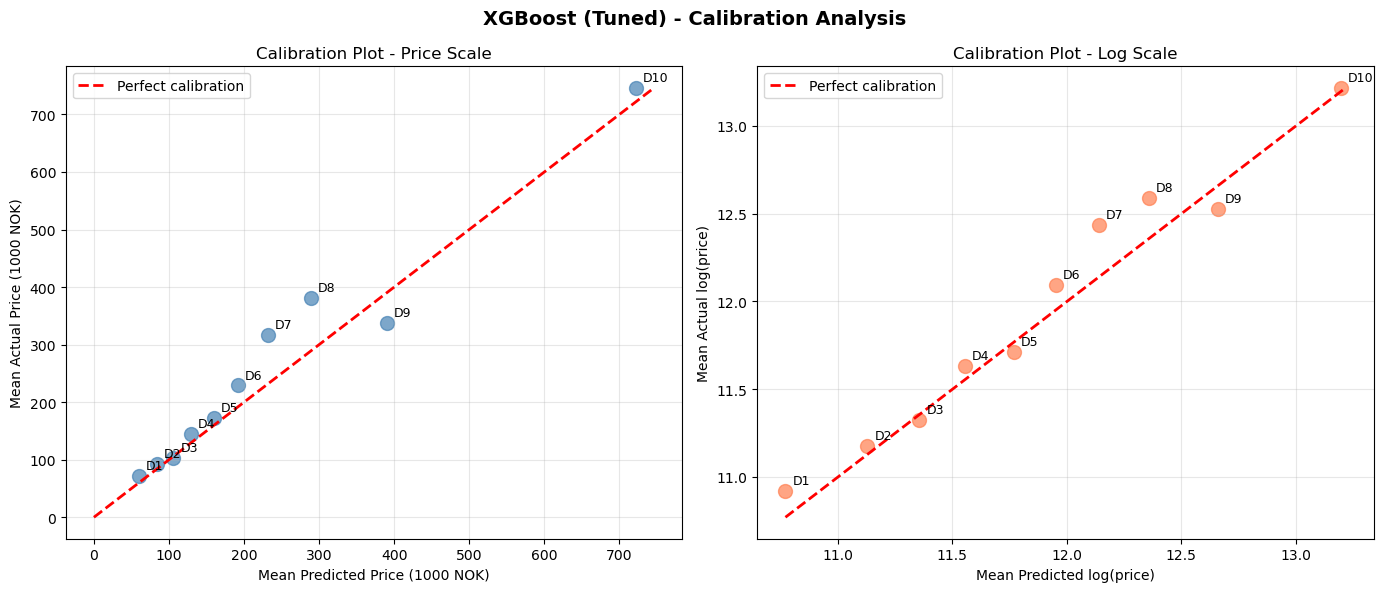

✓ Saved: xgb_tuned_calibration_plot.png

[CALIBRATION ERROR METRICS]
  Expected Calibration Error (ECE): 34,148 NOK
  Maximum Calibration Error (MCE):  92,901 NOK (Decile 8)
  RMS Calibration Error (RMSCE):    45,884 NOK


In [114]:
# =========================================================
# CALIBRATION ANALYSIS (TUNED MODEL)
# =========================================================

print("="*70)
print("CALIBRATION ANALYSIS (TUNED MODEL)")
print("="*70)

# Number of bins (deciles)
n_bins = 10

# Create bins based on predicted prices
pred_quantiles = pd.qcut(pred_test_price_tuned, q=n_bins, labels=False, duplicates='drop')

# Calculate mean predicted and actual for each bin
calibration_df = pd.DataFrame({
    'predicted': pred_test_price_tuned,
    'actual': y_test_price,
    'predicted_log': pred_test_tuned,
    'actual_log': y_test.values,
    'bin': pred_quantiles
})

calibration_summary = calibration_df.groupby('bin').agg(
    mean_predicted=('predicted', 'mean'),
    mean_actual=('actual', 'mean'),
    mean_predicted_log=('predicted_log', 'mean'),
    mean_actual_log=('actual_log', 'mean'),
    count=('actual', 'count')
).reset_index()

# Calculate differences
calibration_summary['diff_price'] = calibration_summary['mean_actual'] - calibration_summary['mean_predicted']
calibration_summary['diff_pct'] = (calibration_summary['diff_price'] / calibration_summary['mean_predicted']) * 100
calibration_summary['diff_log'] = calibration_summary['mean_actual_log'] - calibration_summary['mean_predicted_log']

print(f"\n[CALIBRATION BY PREDICTION DECILE]")
print(f"{'Decile':<8} {'Pred':>12} {'Actual':>12} {'Diff':>10} {'Diff %':>8} {'Pred Log':>10} {'Act Log':>10} {'Diff Log':>10} {'N':>5}")
print("-" * 95)

for _, row in calibration_summary.iterrows():
    print(f"D{int(row['bin'])+1:<7} {row['mean_predicted']:>12,.0f} {row['mean_actual']:>12,.0f} "
          f"{row['diff_price']:>+10,.0f} {row['diff_pct']:>+7.1f}% "
          f"{row['mean_predicted_log']:>10.3f} {row['mean_actual_log']:>10.3f} {row['diff_log']:>+10.3f} "
          f"{int(row['count']):>5}")

# ---------------------------------------------------------
# Summary statistics
# ---------------------------------------------------------
mean_diff = calibration_summary['diff_price'].mean()
low_decile_bias = calibration_summary[calibration_summary['bin'] <= 2]['diff_price'].mean()
high_decile_bias = calibration_summary[calibration_summary['bin'] >= 7]['diff_price'].mean()

print(f"\n[CALIBRATION SUMMARY]")
print(f"  Mean difference across deciles: {mean_diff:+,.0f} NOK")
print(f"  Low deciles (D1-D3) avg bias:   {low_decile_bias:+,.0f} NOK")
print(f"  High deciles (D8-D10) avg bias: {high_decile_bias:+,.0f} NOK")

if mean_diff > 0:
    print(f"  ⚠ Model underpredicts expensive horses")
else:
    print(f"  ⚠ Model overpredicts expensive horses")

# ---------------------------------------------------------
# Calibration Plot
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Price scale
ax1 = axes[0]
ax1.scatter(calibration_summary['mean_predicted']/1000, 
            calibration_summary['mean_actual']/1000, 
            s=100, alpha=0.7, c='steelblue')

# Add decile labels
for _, row in calibration_summary.iterrows():
    ax1.annotate(f"D{int(row['bin'])+1}", 
                 (row['mean_predicted']/1000, row['mean_actual']/1000),
                 textcoords="offset points", xytext=(5,5), fontsize=9)

# Perfect calibration line
max_val = max(calibration_summary['mean_predicted'].max(), 
              calibration_summary['mean_actual'].max()) / 1000
ax1.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect calibration')
ax1.set_xlabel('Mean Predicted Price (1000 NOK)')
ax1.set_ylabel('Mean Actual Price (1000 NOK)')
ax1.set_title('Calibration Plot - Price Scale')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log scale
ax2 = axes[1]
ax2.scatter(calibration_summary['mean_predicted_log'], 
            calibration_summary['mean_actual_log'], 
            s=100, alpha=0.7, c='coral')

for _, row in calibration_summary.iterrows():
    ax2.annotate(f"D{int(row['bin'])+1}", 
                 (row['mean_predicted_log'], row['mean_actual_log']),
                 textcoords="offset points", xytext=(5,5), fontsize=9)

max_log = max(calibration_summary['mean_predicted_log'].max(), 
              calibration_summary['mean_actual_log'].max())
min_log = min(calibration_summary['mean_predicted_log'].min(), 
              calibration_summary['mean_actual_log'].min())
ax2.plot([min_log, max_log], [min_log, max_log], 'r--', lw=2, label='Perfect calibration')
ax2.set_xlabel('Mean Predicted log(price)')
ax2.set_ylabel('Mean Actual log(price)')
ax2.set_title('Calibration Plot - Log Scale')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('XGBoost (Tuned) - Calibration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_tuned_calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: xgb_tuned_calibration_plot.png")

# ---------------------------------------------------------
# Calibration Error Metrics
# ---------------------------------------------------------
ece = calibration_summary['diff_price'].abs().mean()
mce = calibration_summary['diff_price'].abs().max()
rmsce = np.sqrt((calibration_summary['diff_price']**2).mean())

print(f"\n[CALIBRATION ERROR METRICS]")
print(f"  Expected Calibration Error (ECE): {ece:,.0f} NOK")
print(f"  Maximum Calibration Error (MCE):  {mce:,.0f} NOK (Decile {calibration_summary['diff_price'].abs().idxmax() + 1})")
print(f"  RMS Calibration Error (RMSCE):    {rmsce:,.0f} NOK")

In [115]:
# =========================================================
# CALIBRATION TABLE - EXPORT TO WORD (DYNAMIC)
# =========================================================

from docx import Document

doc = Document()

# ---------------------------------------------------------
# Table 1: Calibration by Decile (from calibration_summary DataFrame)
# ---------------------------------------------------------
doc.add_heading('Table X: Calibration by Prediction Decile', level=2)

table1 = doc.add_table(rows=len(calibration_summary) + 1, cols=5)
table1.style = 'Table Grid'

headers1 = ['Decile', 'Mean Predicted (SEK)', 'Mean Actual (SEK)', 'Difference (SEK)', 'Difference (%)']
for i, h in enumerate(headers1):
    table1.rows[0].cells[i].text = h

for row_idx, row in calibration_summary.iterrows():
    table1.rows[row_idx + 1].cells[0].text = f"D{int(row['bin']) + 1}"
    table1.rows[row_idx + 1].cells[1].text = f"{row['mean_predicted']:,.0f}"
    table1.rows[row_idx + 1].cells[2].text = f"{row['mean_actual']:,.0f}"
    table1.rows[row_idx + 1].cells[3].text = f"{row['diff_price']:+,.0f}"
    table1.rows[row_idx + 1].cells[4].text = f"{row['diff_pct']:+.1f}%"

doc.add_paragraph()

# ---------------------------------------------------------
# Table 2: Calibration Summary by Group (calculated dynamically)
# ---------------------------------------------------------
doc.add_heading('Table X: Calibration Summary by Decile Group', level=2)

# Calculate group averages
low_bias = calibration_summary[calibration_summary['bin'] <= 2]['diff_price'].mean()
mid_bias = calibration_summary[(calibration_summary['bin'] >= 3) & (calibration_summary['bin'] <= 6)]['diff_price'].mean()
high_bias = calibration_summary[calibration_summary['bin'] >= 7]['diff_price'].mean()

# Determine pattern labels
def get_pattern(bias):
    if abs(bias) < 10000:
        return "Well calibrated"
    elif bias > 0:
        return "Underprediction"
    else:
        return "Overprediction"

table2 = doc.add_table(rows=4, cols=3)
table2.style = 'Table Grid'

headers2 = ['Decile Group', 'Avg Bias (SEK)', 'Pattern']
for i, h in enumerate(headers2):
    table2.rows[0].cells[i].text = h

summary_data = [
    ['D1–D3 (low)', f'{low_bias:+,.0f}', get_pattern(low_bias)],
    ['D4–D7 (mid)', f'{mid_bias:+,.0f}', get_pattern(mid_bias)],
    ['D8–D10 (high)', f'{high_bias:+,.0f}', get_pattern(high_bias)]
]

for row_idx, row_data in enumerate(summary_data, start=1):
    for col_idx, value in enumerate(row_data):
        table2.rows[row_idx].cells[col_idx].text = value

# ---------------------------------------------------------
# Print summary for reference
# ---------------------------------------------------------
print("[CALIBRATION SUMMARY]")
print(f"  Low deciles (D1-D3):  {low_bias:+,.0f} SEK - {get_pattern(low_bias)}")
print(f"  Mid deciles (D4-D7):  {mid_bias:+,.0f} SEK - {get_pattern(mid_bias)}")
print(f"  High deciles (D8-D10): {high_bias:+,.0f} SEK - {get_pattern(high_bias)}")

# Save
doc.save('XGB_calibration_tables.docx')
print("\n✓ Saved: XGB_calibration_tables.docx")

[CALIBRATION SUMMARY]
  Low deciles (D1-D3):  +5,627 SEK - Well calibrated
  Mid deciles (D4-D7):  +37,219 SEK - Underprediction
  High deciles (D8-D10): +21,467 SEK - Underprediction

✓ Saved: XGB_calibration_tables.docx


FEATURE IMPORTANCE ANALYSIS

[CALCULATING PERMUTATION IMPORTANCE]
  This may take a minute...
  ✓ Done

[COMPARISON: GAIN vs PERMUTATION IMPORTANCE]


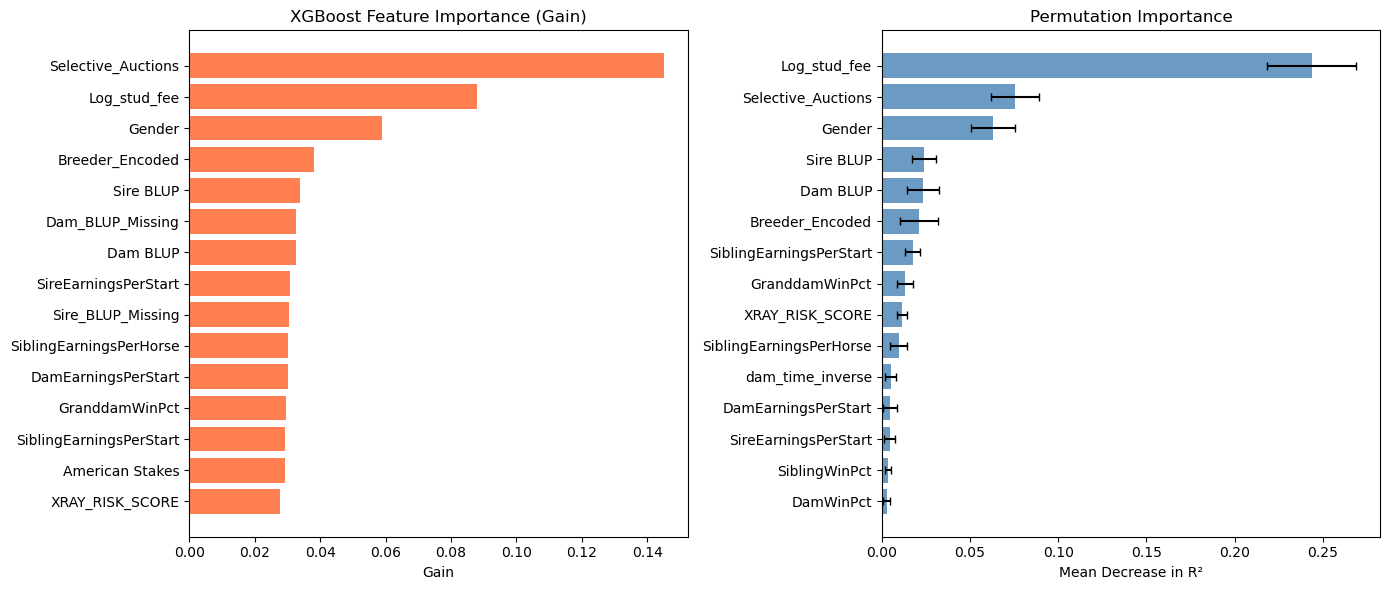

✓ Saved: xgb_importance_comparison.svg


In [116]:
# =========================================================
# FEATURE IMPORTANCE ANALYSIS
# =========================================================

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

from sklearn.inspection import permutation_importance

# ---------------------------------------------------------
# Calculate Permutation Importance
# ---------------------------------------------------------
print("\n[CALCULATING PERMUTATION IMPORTANCE]")
print("  This may take a minute...")

perm_imp = permutation_importance(
    best_model, 
    X_test.values, 
    y_test.values, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1
)

print("  ✓ Done")

# ---------------------------------------------------------
# Compare Gain vs Permutation Importance
# ---------------------------------------------------------
print("\n[COMPARISON: GAIN vs PERMUTATION IMPORTANCE]")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------------------------------------
# XGBoost Gain (sorted correctly)
# ---------------------------------------------------------
ax1 = axes[0]

# Get gain importance using sklearn API
gain_values = best_model.feature_importances_

gain_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': gain_values
}).sort_values('Importance', ascending=False)

top_15_gain = gain_df.head(15)
ax1.barh(range(15), top_15_gain['Importance'].values[::-1], color='coral')
ax1.set_yticks(range(15))
ax1.set_yticklabels(top_15_gain['Feature'].values[::-1])
ax1.set_xlabel('Gain')
ax1.set_title('XGBoost Feature Importance (Gain)')

# ---------------------------------------------------------
# Permutation Importance (with error bars)
# ---------------------------------------------------------
ax2 = axes[1]

sorted_idx_perm = perm_imp.importances_mean.argsort()[::-1][:15]
ax2.barh(range(15), perm_imp.importances_mean[sorted_idx_perm][::-1],
         xerr=perm_imp.importances_std[sorted_idx_perm][::-1],
         capsize=3, color='steelblue', alpha=0.8)
ax2.set_yticks(range(15))
ax2.set_yticklabels([FEATURES[i] for i in sorted_idx_perm][::-1])
ax2.set_xlabel('Mean Decrease in R²')
ax2.set_title('Permutation Importance')

plt.tight_layout()
plt.savefig('xgb_importance_comparison.svg', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: xgb_importance_comparison.svg")


[COMPARISON: GAIN vs PERMUTATION IMPORTANCE]


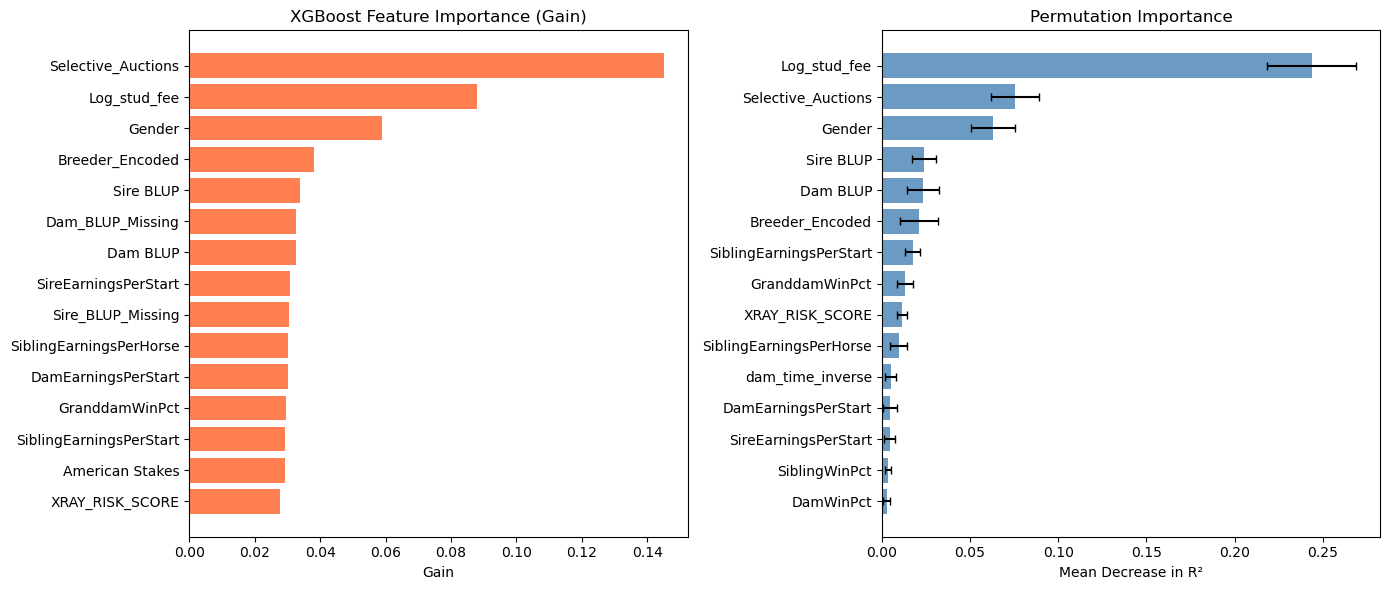

✓ Saved: xgb_importance_comparison.svg


In [117]:
# ---------------------------------------------------------
# Compare Gain vs Permutation Importance
# ---------------------------------------------------------
print("\n[COMPARISON: GAIN vs PERMUTATION IMPORTANCE]")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------------------------------------
# XGBoost Gain (sorted correctly)
# ---------------------------------------------------------
ax1 = axes[0]

# Get gain importance using sklearn API
gain_values = best_model.feature_importances_

# Create dataframe and sort by importance (descending)
gain_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': gain_values
}).sort_values('Importance', ascending=False)

# Plot top 15 (sorted high to low, displayed bottom to top)
top_15_gain = gain_df.head(15)
ax1.barh(range(15), top_15_gain['Importance'].values[::-1], color='coral')
ax1.set_yticks(range(15))
ax1.set_yticklabels(top_15_gain['Feature'].values[::-1])
ax1.set_xlabel('Gain')
ax1.set_title('XGBoost Feature Importance (Gain)')

# ---------------------------------------------------------
# Permutation Importance (with error bars)
# ---------------------------------------------------------
ax2 = axes[1]

sorted_idx_perm = perm_imp.importances_mean.argsort()[::-1][:15]
ax2.barh(range(15), perm_imp.importances_mean[sorted_idx_perm][::-1],
         xerr=perm_imp.importances_std[sorted_idx_perm][::-1],
         capsize=3, color='steelblue', alpha=0.8)
ax2.set_yticks(range(15))
ax2.set_yticklabels([FEATURES[i] for i in sorted_idx_perm][::-1])
ax2.set_xlabel('Mean Decrease in R²')
ax2.set_title('Permutation Importance')

plt.tight_layout()
plt.savefig('xgb_importance_comparison.svg', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: xgb_importance_comparison.svg")

PARTIAL DEPENDENCE PLOTS

[PLOTTING PDPs FOR TOP 6 FEATURES]
  - Log_stud_fee
  - Selective_Auctions
  - Gender
  - Sire BLUP
  - Dam BLUP
  - Breeder_Encoded


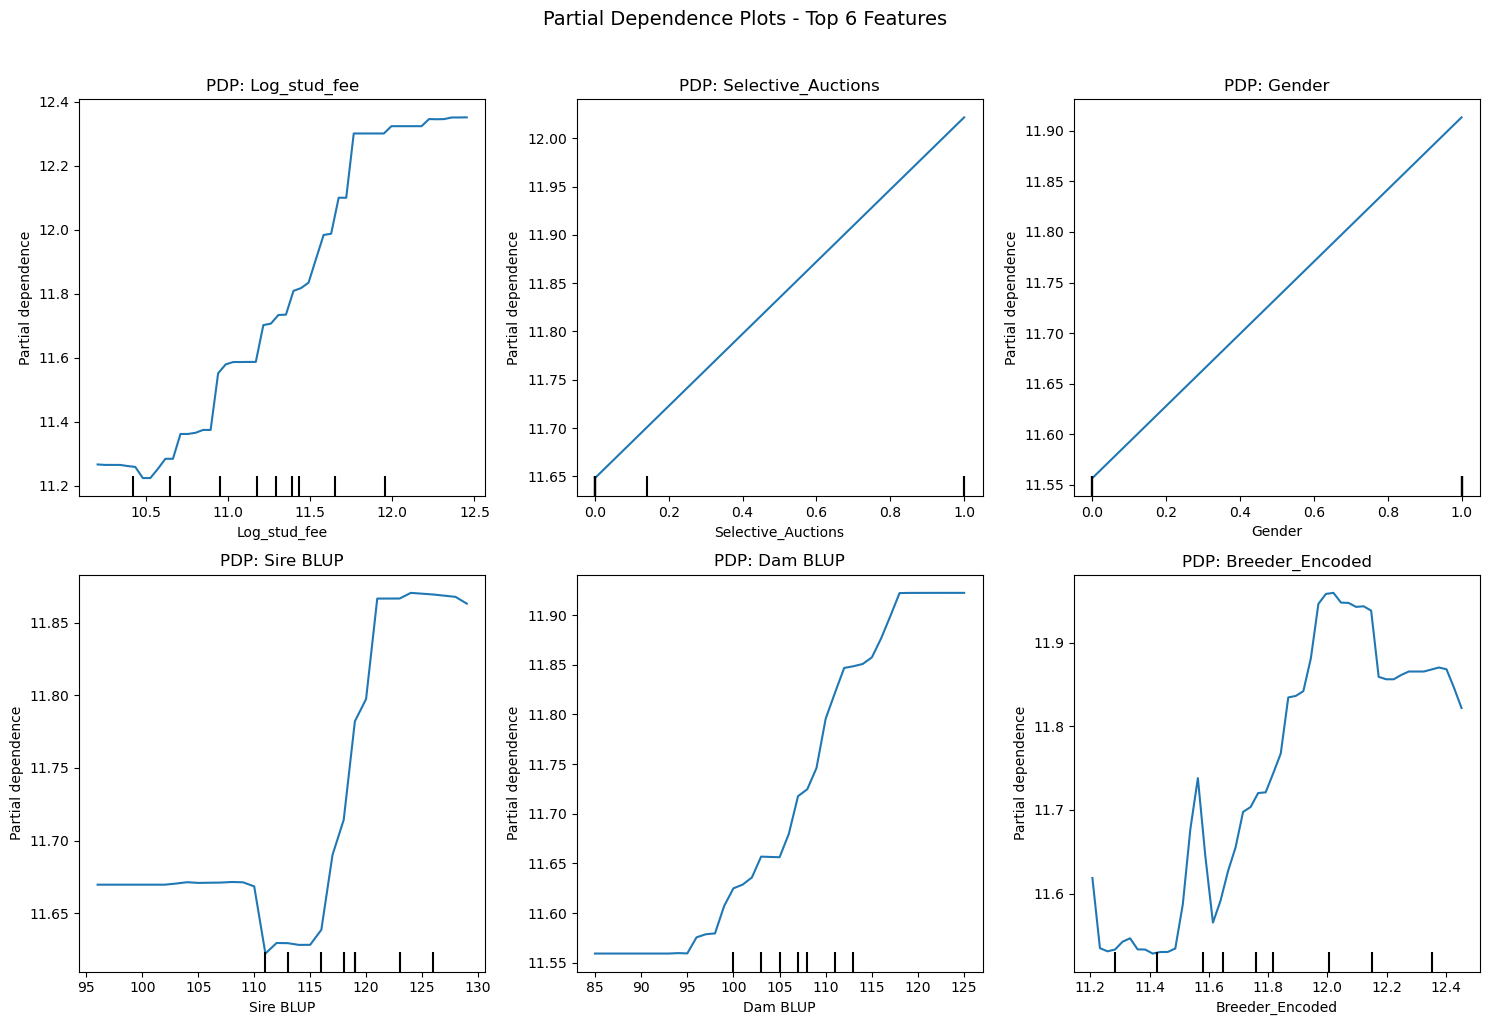

In [118]:
# =========================================================
# PARTIAL DEPENDENCE PLOTS
# =========================================================

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

print("="*70)
print("PARTIAL DEPENDENCE PLOTS")
print("="*70)

# Select top features for PDP (based on permutation importance)
top_features_idx = perm_imp.importances_mean.argsort()[::-1][:6]
top_feature_names = [FEATURES[i] for i in top_features_idx]

print(f"\n[PLOTTING PDPs FOR TOP 6 FEATURES]")
for f in top_feature_names:
    print(f"  - {f}")

# ---------------------------------------------------------
# Individual PDPs for top features
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat_idx in enumerate(top_features_idx):
    PartialDependenceDisplay.from_estimator(
        best_model, X_train, features=[feat_idx],
        ax=axes[i], grid_resolution=50,
        feature_names=FEATURES
    )
    axes[i].set_title(f'PDP: {FEATURES[feat_idx]}')

plt.suptitle('Partial Dependence Plots - Top 6 Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [119]:
# =========================================================
# SHAP VALUES
# =========================================================

import shap

print("="*70)
print("SHAP ANALYSIS")
print("="*70)

print("\n[COMPUTING SHAP VALUES]")
print("  Creating TreeExplainer...")

# Create SHAP explainer for tree-based models
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set
print("  Computing SHAP values for test set...")
shap_values = explainer.shap_values(X_test.values)

print(f"  SHAP values shape: {shap_values.shape}")
print("  Done!")

SHAP ANALYSIS

[COMPUTING SHAP VALUES]
  Creating TreeExplainer...
  Computing SHAP values for test set...
  SHAP values shape: (510, 30)
  Done!



[SHAP SUMMARY PLOT - BEESWARM]
  Shows feature importance AND direction of effect
  Red = high feature value, Blue = low feature value


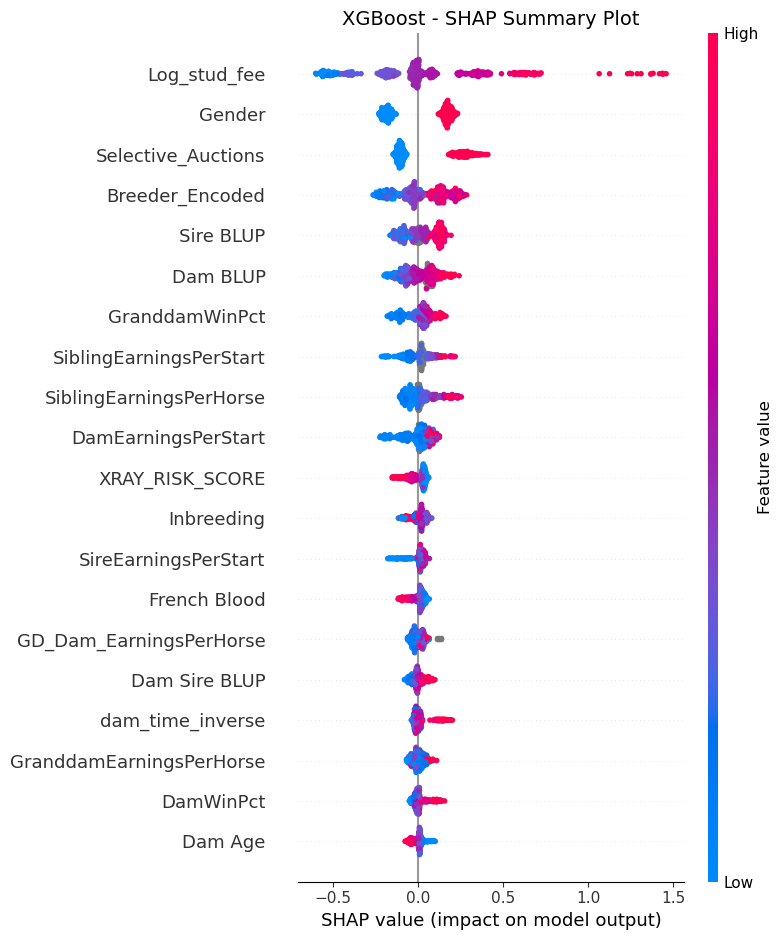

In [120]:
# ---------------------------------------------------------
# SHAP Summary Plot (Beeswarm)
# ---------------------------------------------------------

print("\n[SHAP SUMMARY PLOT - BEESWARM]")
print("  Shows feature importance AND direction of effect")
print("  Red = high feature value, Blue = low feature value")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('XGBoost - SHAP Summary Plot', fontsize=14)
plt.tight_layout()
plt.savefig('SHAP_Summary_Plot.svg',  bbox_inches='tight')
plt.show()





[SHAP FEATURE IMPORTANCE - BAR PLOT]


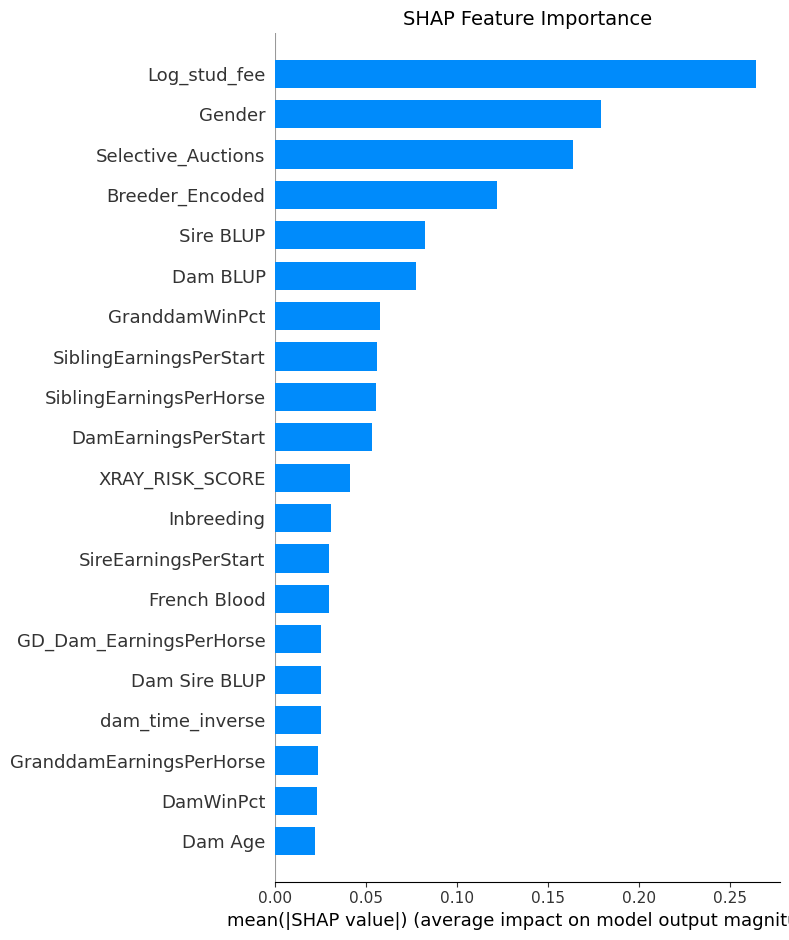

In [121]:
# ---------------------------------------------------------
# SHAP Bar Plot (Feature Importance)
# ---------------------------------------------------------

print("\n[SHAP FEATURE IMPORTANCE - BAR PLOT]")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, 
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()


[SHAP DEPENDENCE PLOTS]
  Similar to PDP but shows individual observations
  Color indicates interaction with auto-detected feature


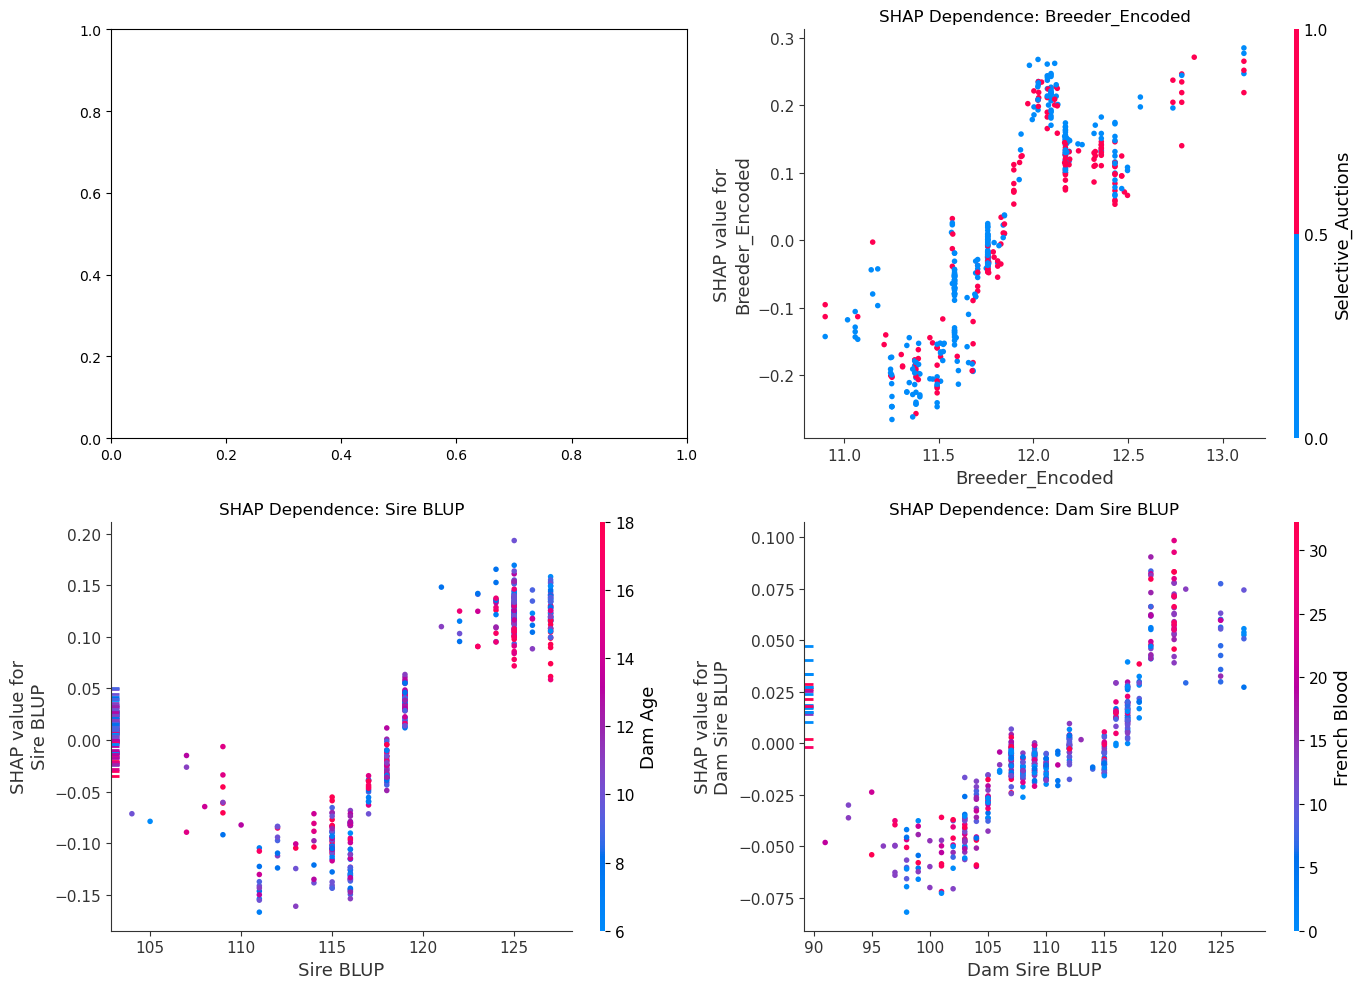

In [122]:
# ---------------------------------------------------------
# SHAP Dependence Plots for Key Features
# ---------------------------------------------------------

print("\n[SHAP DEPENDENCE PLOTS]")
print("  Similar to PDP but shows individual observations")
print("  Color indicates interaction with auto-detected feature")

# Key features to plot
key_features = ['log_stud_fee', 'Breeder_Encoded']

# Add BLUP features if they exist
if 'Sire BLUP' in FEATURES:
    key_features.append('Sire BLUP')
if 'Dam Sire BLUP' in FEATURES:
    key_features.append('Dam Sire BLUP')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features[:4]):
    if feat in FEATURES:
        feat_idx = FEATURES.index(feat)
        plt.sca(axes[i])
        shap.dependence_plot(
            feat_idx, shap_values, X_test,
            feature_names=FEATURES,
            interaction_index='auto',
            ax=axes[i], show=False
        )
        axes[i].set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.show()


[SHAP WATERFALL - INDIVIDUAL PREDICTION EXPLANATION]
  Showing how features contribute to prediction for specific horses

  Highest Priced Horse (Test Set)
    Actual log(price): 14.914
    Predicted log(price): 13.911
    Actual price: 3,000,000 NOK
    Predicted price: 1,100,560 NOK


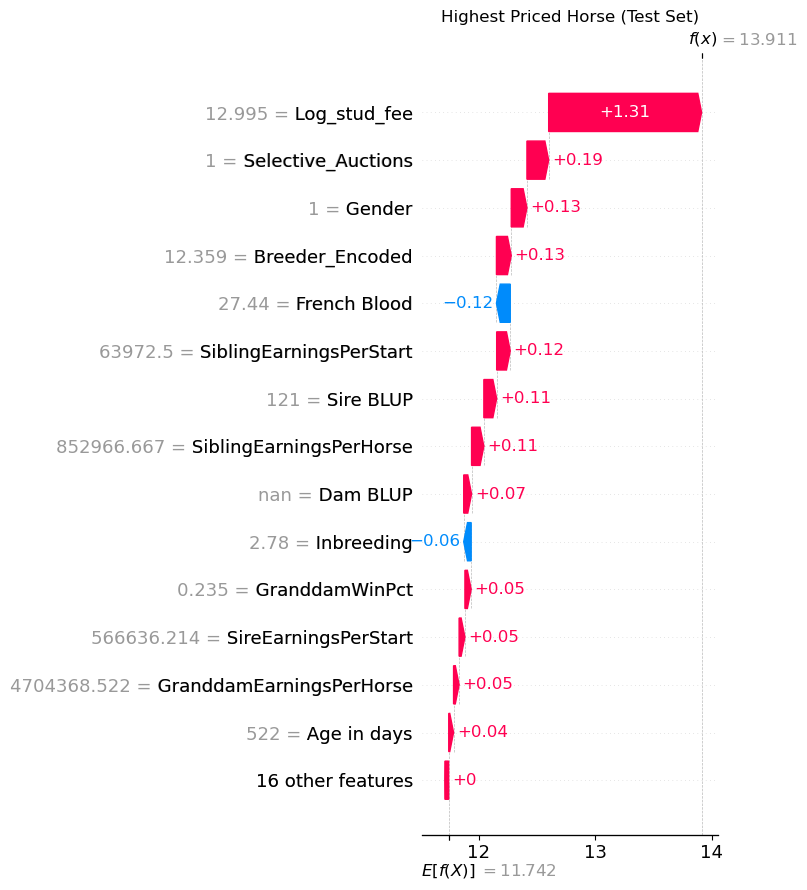


  Median Priced Horse (Test Set)
    Actual log(price): 11.918
    Predicted log(price): 12.316
    Actual price: 150,000 NOK
    Predicted price: 223,137 NOK


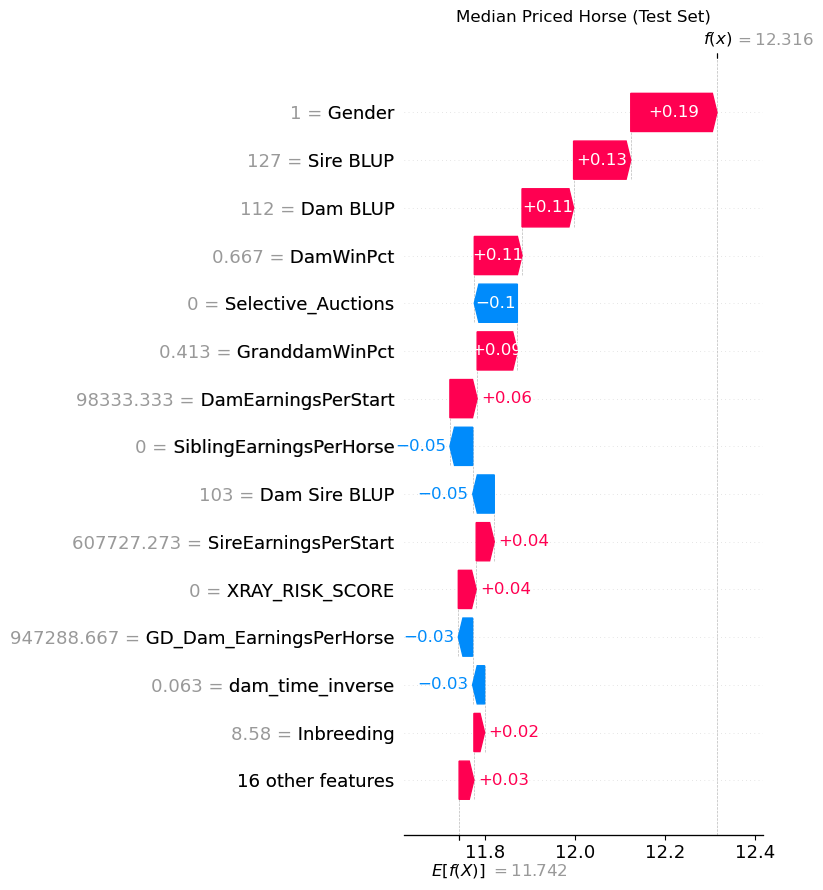


  Lowest Priced Horse (Test Set)
    Actual log(price): 10.127
    Predicted log(price): 11.172
    Actual price: 25,000 NOK
    Predicted price: 71,127 NOK


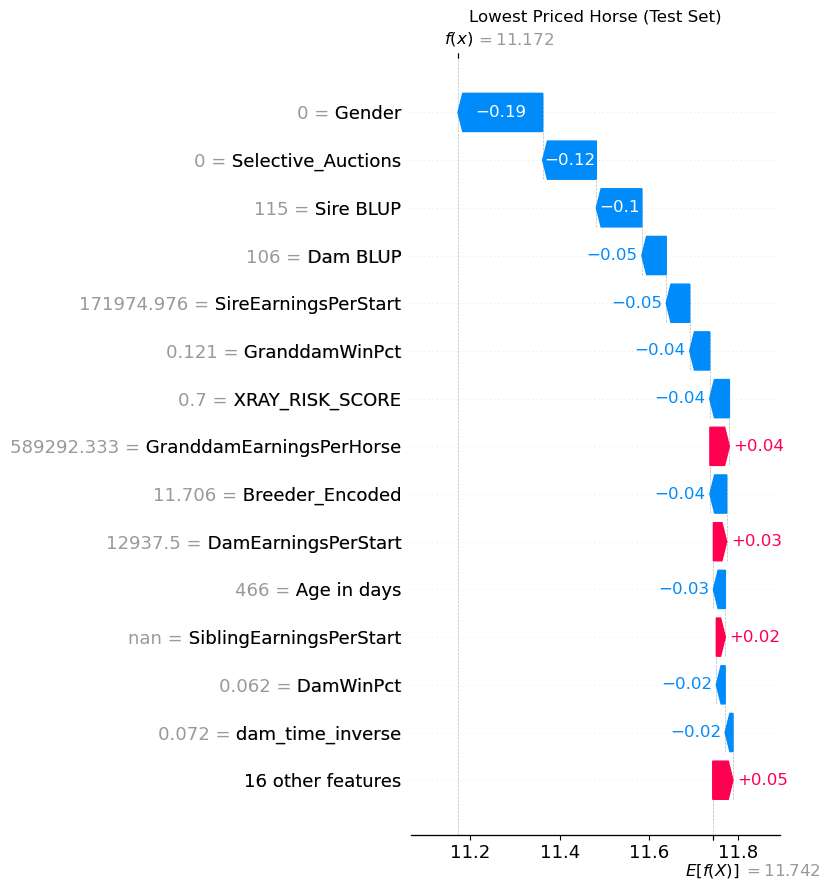

In [123]:
# ---------------------------------------------------------
# SHAP Waterfall for Individual Predictions
# ---------------------------------------------------------

print("\n[SHAP WATERFALL - INDIVIDUAL PREDICTION EXPLANATION]")
print("  Showing how features contribute to prediction for specific horses")

# Find interesting cases: highest priced, lowest priced, median
highest_idx = y_test.values.argmax()
lowest_idx = y_test.values.argmin()
median_idx = np.abs(y_test.values - np.median(y_test.values)).argmin()

cases = [
    ('Highest Priced Horse (Test Set)', highest_idx),
    ('Median Priced Horse (Test Set)', median_idx),
    ('Lowest Priced Horse (Test Set)', lowest_idx),
]

for title, idx in cases:
    print(f"\n  {title}")
    print(f"    Actual log(price): {y_test.values[idx]:.3f}")
   # print(f"    Predicted log(price): {pred_test[idx]:.3f}")
    print(f"    Predicted log(price): {pred_test_tuned[idx]:.3f}")  # ← pred_test_tuned
    print(f"    Actual price: {np.exp(y_test.values[idx]):,.0f} NOK")
 #   print(f"    Predicted price: {np.exp(pred_test[idx]):,.0f} NOK")
    print(f"    Predicted price: {np.exp(pred_test_tuned[idx]):,.0f} NOK")  # ← pred_test_tuned

  
    # Create SHAP explanation object
    shap_exp = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.values[idx],
        feature_names=FEATURES
    )
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, show=False, max_display=15)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [124]:
# =========================================================
# IMPORTANCE COMPARISON SUMMARY
# =========================================================
print("="*70)
print("IMPORTANCE COMPARISON SUMMARY")
print("="*70)

# ---------------------------------------------------------
# Get XGBoost Gain importance (using sklearn API - simpler)
# ---------------------------------------------------------
gain_values = best_model.feature_importances_

# ---------------------------------------------------------
# Calculate mean absolute SHAP values per feature
# ---------------------------------------------------------
shap_importance = np.abs(shap_values).mean(axis=0)

# ---------------------------------------------------------
# Create comparison DataFrame
# ---------------------------------------------------------
comparison_df = pd.DataFrame({
    'Feature': FEATURES,
    'Gain': gain_values,
    'Permutation': perm_imp.importances_mean,
    'SHAP': shap_importance
})




# Calculate ranks for each method
for col in ['Gain', 'Permutation', 'SHAP']:
    comparison_df[f'{col}_Rank'] = comparison_df[col].rank(ascending=False, method='min').astype(int)

# Sort by average rank
#comparison_df['Avg_Rank'] = comparison_df[['Gain_Rank', 'Permutation_Rank', 'SHAP_Rank']].mean(axis=1)
#comparison_df = comparison_df.sort_values('Avg_Rank')

print("\n[FEATURE RANKING BY DIFFERENT METHODS]")
print(comparison_df[['Feature', 'Gain_Rank', 'Permutation_Rank', 'SHAP_Rank']].head(15).to_string(index=False))

# ---------------------------------------------------------
# Correlation between methods
# ---------------------------------------------------------
print("\n[CORRELATION BETWEEN IMPORTANCE METHODS]")
print(f"  Gain vs Permutation: {comparison_df['Gain'].corr(comparison_df['Permutation']):.3f}")
print(f"  Gain vs SHAP:        {comparison_df['Gain'].corr(comparison_df['SHAP']):.3f}")
print(f"  Permutation vs SHAP: {comparison_df['Permutation'].corr(comparison_df['SHAP']):.3f}")

# ---------------------------------------------------------
# Top 5 by each method
# ---------------------------------------------------------
print("\n[TOP 5 FEATURES BY EACH METHOD]")
print(f"  {'Gain':<25} {'Permutation':<25} {'SHAP':<25}")
print(f"  {'-'*25} {'-'*25} {'-'*25}")

top_gain = comparison_df.nsmallest(5, 'Gain_Rank')['Feature'].tolist()
top_perm = comparison_df.nsmallest(5, 'Permutation_Rank')['Feature'].tolist()
top_shap = comparison_df.nsmallest(5, 'SHAP_Rank')['Feature'].tolist()

for i in range(5):
    print(f"  {top_gain[i]:<25} {top_perm[i]:<25} {top_shap[i]:<25}")

# Consensus
consensus = set(top_gain) & set(top_perm) & set(top_shap)
print(f"\n[CONSENSUS] Features in top 5 by ALL methods: {consensus if consensus else 'None'}")

IMPORTANCE COMPARISON SUMMARY

[FEATURE RANKING BY DIFFERENT METHODS]
             Feature  Gain_Rank  Permutation_Rank  SHAP_Rank
        French Blood         21                19         14
          Inbreeding         25                17         12
         Age in days         22                18         21
     American Stakes         14                28         24
     XRAY_RISK_SCORE         15                 9         11
        Log_stud_fee          2                 1          1
   First_Season_Flag         27                30         25
SireEarningsPerStart          8                13         13
    dam_time_inverse         16                11         17
           DamWinPct         24                15         19
 DamEarningsPerStart         11                12         10
             Dam Age         26                16         20
            Dam BLUP          7                 5          6
           Sire BLUP          5                 4          5
       Dam Sire

In [125]:
# =========================================================
# IMPORTANCE COMPARISON SUMMARY - EXPORT TO WORD
# =========================================================
from docx import Document

print("="*70)
print("IMPORTANCE COMPARISON SUMMARY")
print("="*70)

# ---------------------------------------------------------
# Get XGBoost Gain importance (using sklearn API - simpler)
# ---------------------------------------------------------
gain_values = best_model.feature_importances_

# ---------------------------------------------------------
# Calculate mean absolute SHAP values per feature
# ---------------------------------------------------------
shap_importance = np.abs(shap_values).mean(axis=0)

# ---------------------------------------------------------
# Create comparison DataFrame
# ---------------------------------------------------------
comparison_df = pd.DataFrame({
    'Feature': FEATURES,
    'Gain': gain_values,
    'Permutation': perm_imp.importances_mean,
    'SHAP': shap_importance
})

# Calculate ranks for each method
for col in ['Gain', 'Permutation', 'SHAP']:
    comparison_df[f'{col}_Rank'] = comparison_df[col].rank(ascending=False, method='min').astype(int)

print("\n[FEATURE RANKING BY DIFFERENT METHODS]")
print(comparison_df[['Feature', 'Gain_Rank', 'Permutation_Rank', 'SHAP_Rank']].to_string(index=False))

# ---------------------------------------------------------
# Correlation between methods
# ---------------------------------------------------------
corr_gain_perm = comparison_df['Gain'].corr(comparison_df['Permutation'])
corr_gain_shap = comparison_df['Gain'].corr(comparison_df['SHAP'])
corr_perm_shap = comparison_df['Permutation'].corr(comparison_df['SHAP'])

print("\n[CORRELATION BETWEEN IMPORTANCE METHODS]")
print(f"  Gain vs Permutation: {corr_gain_perm:.3f}")
print(f"  Gain vs SHAP:        {corr_gain_shap:.3f}")
print(f"  Permutation vs SHAP: {corr_perm_shap:.3f}")

# ---------------------------------------------------------
# Top 5 by each method
# ---------------------------------------------------------
top_gain = comparison_df.nsmallest(5, 'Gain_Rank')['Feature'].tolist()
top_perm = comparison_df.nsmallest(5, 'Permutation_Rank')['Feature'].tolist()
top_shap = comparison_df.nsmallest(5, 'SHAP_Rank')['Feature'].tolist()

print("\n[TOP 5 FEATURES BY EACH METHOD]")
print(f"  {'Gain':<25} {'Permutation':<25} {'SHAP':<25}")
print(f"  {'-'*25} {'-'*25} {'-'*25}")
for i in range(5):
    print(f"  {top_gain[i]:<25} {top_perm[i]:<25} {top_shap[i]:<25}")

# Consensus
consensus = set(top_gain) & set(top_perm) & set(top_shap)
print(f"\n[CONSENSUS] Features in top 5 by ALL methods: {consensus if consensus else 'None'}")

# ---------------------------------------------------------
# Export to Word
# ---------------------------------------------------------
doc = Document()

# Table 1: Feature Ranking by Different Methods
doc.add_heading('Table X: Feature Importance Ranking by Method', level=2)

# Sort by average rank for cleaner presentation
comparison_df['Avg_Rank'] = comparison_df[['Gain_Rank', 'Permutation_Rank', 'SHAP_Rank']].mean(axis=1)
comparison_sorted = comparison_df.sort_values('Avg_Rank')

table1 = doc.add_table(rows=len(FEATURES)+1, cols=4)
table1.style = 'Table Grid'

headers1 = ['Feature', 'Gain', 'Permutation', 'SHAP']
for i, h in enumerate(headers1):
    table1.rows[0].cells[i].text = h

for row_idx, (_, row) in enumerate(comparison_sorted.iterrows(), start=1):
    table1.rows[row_idx].cells[0].text = row['Feature']
    table1.rows[row_idx].cells[1].text = str(row['Gain_Rank'])
    table1.rows[row_idx].cells[2].text = str(row['Permutation_Rank'])
    table1.rows[row_idx].cells[3].text = str(row['SHAP_Rank'])

doc.add_paragraph()

# Table 2: Correlation Between Methods
doc.add_heading('Table X: Correlation Between Importance Methods', level=2)

table2 = doc.add_table(rows=4, cols=2)
table2.style = 'Table Grid'

headers2 = ['Method Pair', 'Correlation']
for i, h in enumerate(headers2):
    table2.rows[0].cells[i].text = h

corr_data = [
    ['Gain vs Permutation', f'{corr_gain_perm:.3f}'],
    ['Gain vs SHAP', f'{corr_gain_shap:.3f}'],
    ['Permutation vs SHAP', f'{corr_perm_shap:.3f}']
]

for row_idx, row_data in enumerate(corr_data, start=1):
    for col_idx, value in enumerate(row_data):
        table2.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph()

# Table 3: Top 5 Features by Each Method
doc.add_heading('Table X: Top 5 Features by Each Method', level=2)

table3 = doc.add_table(rows=6, cols=3)
table3.style = 'Table Grid'

headers3 = ['Gain', 'Permutation', 'SHAP']
for i, h in enumerate(headers3):
    table3.rows[0].cells[i].text = h

for row_idx in range(5):
    table3.rows[row_idx+1].cells[0].text = top_gain[row_idx]
    table3.rows[row_idx+1].cells[1].text = top_perm[row_idx]
    table3.rows[row_idx+1].cells[2].text = top_shap[row_idx]

doc.add_paragraph()

# Add consensus note
consensus_text = ', '.join(sorted(consensus)) if consensus else 'None'
doc.add_paragraph(f'Consensus (top 5 by all methods): {consensus_text}')

# Save
doc.save('XGBoost_feature_importance.docx')
print(f"\n✓ Saved: XGBoost_feature_importance.docx")

IMPORTANCE COMPARISON SUMMARY

[FEATURE RANKING BY DIFFERENT METHODS]
                 Feature  Gain_Rank  Permutation_Rank  SHAP_Rank
            French Blood         21                19         14
              Inbreeding         25                17         12
             Age in days         22                18         21
         American Stakes         14                28         24
         XRAY_RISK_SCORE         15                 9         11
            Log_stud_fee          2                 1          1
       First_Season_Flag         27                30         25
    SireEarningsPerStart          8                13         13
        dam_time_inverse         16                11         17
               DamWinPct         24                15         19
     DamEarningsPerStart         11                12         10
                 Dam Age         26                16         20
                Dam BLUP          7                 5          6
               Sire 

In [133]:
# =========================================================
# PERFORMANCE METRICS - EXPORT TO WORD
# =========================================================

from docx import Document
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
from scipy.stats import spearmanr, kendalltau
import numpy as np

print("="*70)
print("PERFORMANCE METRICS SUMMARY")
print("="*70)

# ---------------------------------------------------------
# 1. Log-Scale Metrics
# ---------------------------------------------------------
train_r2_log = r2_score(y_train, pred_train_tuned)
test_r2_log = r2_score(y_test, pred_test_tuned)
test_rmse_log = np.sqrt(mean_squared_error(y_test, pred_test_tuned))
test_mae_log = mean_absolute_error(y_test, pred_test_tuned)

print(f"\n[LOG-SCALE METRICS]")
print(f"  Train R²:  {train_r2_log:.4f}")
print(f"  Test R²:   {test_r2_log:.4f}")
print(f"  Test RMSE: {test_rmse_log:.4f}")
print(f"  Test MAE:  {test_mae_log:.4f}")

# ---------------------------------------------------------
# 2. Price-Scale Metrics
# ---------------------------------------------------------
# MdAPE and MAPE
ape_test = np.abs((y_test_price - pred_test_price_tuned) / y_test_price) * 100
mdape = np.median(ape_test)
mape = np.mean(ape_test)

# R² on price scale
test_r2_price = r2_score(y_test_price, pred_test_price_tuned)

print(f"\n[PRICE-SCALE METRICS]")
print(f"  Test R²:   {test_r2_price:.4f}")
print(f"  MdAPE:     {mdape:.1f}%")
print(f"  MAPE:      {mape:.1f}%")

# ---------------------------------------------------------
# 3. Top-Decile / Ranking Metrics
# ---------------------------------------------------------
# Spearman and Kendall
spearman_corr, spearman_p = spearmanr(y_test_price, pred_test_price_tuned)
kendall_corr, kendall_p = kendalltau(y_test_price, pred_test_price_tuned)

# Top-K Hit Rate (K = 10%)
k = int(len(y_test_price) * 0.10)
top_k_pred_idx = np.argsort(pred_test_price_tuned)[::-1][:k]
top_decile_threshold = np.percentile(y_test_price, 90)
actual_top_decile = y_test_price >= top_decile_threshold
hits = actual_top_decile[top_k_pred_idx].sum()
hit_rate = hits / k

# Precision and Recall for top decile
predicted_top_decile = pred_test_price_tuned >= np.percentile(pred_test_price_tuned, 90)
tp = np.sum(actual_top_decile & predicted_top_decile)
fp = np.sum(~actual_top_decile & predicted_top_decile)
fn = np.sum(actual_top_decile & ~predicted_top_decile)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

# NDCG Score
y_true_relevance = (y_test_price / y_test_price.max()).reshape(1, -1)
y_pred_scores = pred_test_price_tuned.reshape(1, -1)
ndcg = ndcg_score(y_true_relevance, y_pred_scores)

print(f"\n[RANKING METRICS]")
print(f"  Spearman ρ:  {spearman_corr:.4f} (p={spearman_p:.2e})")
#print(f"  Kendall τ:   {kendall_corr:.4f} (p={kendall_p:.2e})")
print(f"  NDCG:        {ndcg:.4f}")

print(f"\n[TOP-DECILE IDENTIFICATION]")
print(f"  Hit Rate:    {hit_rate:.1%} ({hits}/{k})")
#print(f"  Precision:   {precision:.3f}")
#print(f"  Recall:      {recall:.3f}")

# ---------------------------------------------------------
# 4. Export to Word
# ---------------------------------------------------------
doc = Document()

# Table 1: Log-Scale Metrics
doc.add_heading('Table X: XGBoost Predictive Performance (Log Scale)', level=2)

table1 = doc.add_table(rows=5, cols=3)
table1.style = 'Table Grid'

headers1 = ['Metric', 'Train', 'Test']
for i, h in enumerate(headers1):
    table1.rows[0].cells[i].text = h

data1 = [
    ['R²', f'{train_r2_log:.4f}', f'{test_r2_log:.4f}'],
    ['RMSE', '—', f'{test_rmse_log:.4f}'],
    ['MAE', '—', f'{test_mae_log:.4f}'],
    ['MdAPE (price scale)', '—', f'{mdape:.1f}%']
]

for row_idx, row_data in enumerate(data1, start=1):
    for col_idx, value in enumerate(row_data):
        table1.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph()

# ---------------------------------------------------------
# Table 2: Ranking Performance
# ---------------------------------------------------------
doc.add_heading('Table X: XGBoost Ranking Performance', level=2)

table2 = doc.add_table(rows=4, cols=2)
table2.style = 'Table Grid'

headers2 = ['Metric', 'Value']
for i, h in enumerate(headers2):
    table2.rows[0].cells[i].text = h

data2 = [
    ['Spearman ρ', f'{spearman_corr:.4f}'],
    ['NDCG', f'{ndcg:.4f}'],
    ['Hit Rate (Top 10%)', f'{hit_rate:.1%} ({hits}/{k})']
]

for row_idx, row_data in enumerate(data2, start=1):
    for col_idx, value in enumerate(row_data):
        table2.rows[row_idx].cells[col_idx].text = value

# Save
doc.save('XGBoost_performance_metrics.docx')
print(f"\n✓ Saved: XGBoost_performance_metrics.docx")

PERFORMANCE METRICS SUMMARY

[LOG-SCALE METRICS]
  Train R²:  0.8115
  Test R²:   0.4612
  Test RMSE: 0.7318
  Test MAE:  0.5983

[PRICE-SCALE METRICS]
  Test R²:   0.3767
  MdAPE:     50.6%
  MAPE:      80.7%

[RANKING METRICS]
  Spearman ρ:  0.6858 (p=4.21e-72)
  NDCG:        0.8458

[TOP-DECILE IDENTIFICATION]
  Hit Rate:    52.9% (27/51)

✓ Saved: XGBoost_performance_metrics.docx


In [ ]:
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Out-of-Fold Predictions
# ---------------------------------------------------------
cv = GroupKFold(n_splits=2)  # Or use more folds if desired
groups = df_train["Year"].values

oof_predictions = cross_val_predict(
    best_model, 
    X_train.values, 
    y_train.values, 
    cv=cv, 
    groups=groups
)

# ---------------------------------------------------------
# Calculate Metrics
# ---------------------------------------------------------
# Training predictions (already have these)
pred_train = best_model.predict(X_train.values)
pred_test = best_model.predict(X_test.values)

# R²
r2_train = r2_score(y_train, pred_train)
r2_oof = r2_score(y_train, oof_predictions)
r2_test = r2_score(y_test, pred_test)

# MAE
mae_train = mean_absolute_error(y_train, pred_train)
mae_oof = mean_absolute_error(y_train, oof_predictions)
mae_test = mean_absolute_error(y_test, pred_test)

# RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_oof = np.sqrt(mean_squared_error(y_train, oof_predictions))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

# ---------------------------------------------------------
# Display Table
# ---------------------------------------------------------
results_df = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE'],
    'Training': [f'{r2_train:.4f}', f'{mae_train:.4f}', f'{rmse_train:.4f}'],
    'OOF': [f'{r2_oof:.4f}', f'{mae_oof:.4f}', f'{rmse_oof:.4f}'],
    'Test': [f'{r2_test:.4f}', f'{mae_test:.4f}', f'{rmse_test:.4f}']
})

print("Table X: Training, Out-of-Fold (OOF) and Test Performance (Log Scale)")
print(results_df.to_string(index=False))

# ---------------------------------------------------------
# Export to Word
# ---------------------------------------------------------
from docx import Document

doc = Document()
doc.add_heading('Table X: Training, Out-of-Fold (OOF) and Test Performance (Log Scale)', level=2)

table = doc.add_table(rows=4, cols=4)
table.style = 'Table Grid'

headers = ['', 'Training', 'OOF', 'Test']
for i, h in enumerate(headers):
    table.rows[0].cells[i].text = h

data = [
    ['R²', f'{r2_train:.4f}', f'{r2_oof:.4f}', f'{r2_test:.4f}'],
    ['MAE', f'{mae_train:.4f}', f'{mae_oof:.4f}', f'{mae_test:.4f}'],
    ['RMSE', f'{rmse_train:.4f}', f'{rmse_oof:.4f}', f'{rmse_test:.4f}']
]

for row_idx, row_data in enumerate(data, start=1):
    for col_idx, value in enumerate(row_data):
        table.rows[row_idx].cells[col_idx].text = value

doc.save('XGBoost_OOF_performance.docx')
print("\n✓ Saved: XGBoost_OOF_performance.docx")

In [135]:
# =========================================================
# OOF PERFORMANCE BY FOLD
# =========================================================
print("\n" + "="*70)
print("OOF PERFORMANCE BY FOLD")
print("="*70)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold

cv = GroupKFold(n_splits=2)
groups = df_train["Year"].values

oof_preds_byfold = np.full(len(y_train), np.nan)

print(f"\n  {'Fold':<6} {'Train on':<12} {'Validate on':<14} {'R²':>8} {'MAE':>8} {'RMSE':>8} {'n':>6}")
print("  " + "-" * 68)

for fold_i, (train_idx, val_idx) in enumerate(cv.split(X_train.values, y_train.values, groups), 1):
    X_tr, X_val = X_train.values[train_idx], X_train.values[val_idx]
    y_tr, y_val = y_train.values[train_idx], y_train.values[val_idx]
    
    fold_model = xgb.XGBRegressor(
        **best_params,
        objective="reg:absoluteerror",
        eval_metric="mae",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    fold_model.fit(X_tr, y_tr)
    fold_preds = fold_model.predict(X_val)
    oof_preds_byfold[val_idx] = fold_preds
    
    # Per-fold metrics (log scale)
    fold_r2   = r2_score(y_val, fold_preds)
    fold_mae  = mean_absolute_error(y_val, fold_preds)
    fold_rmse = np.sqrt(mean_squared_error(y_val, fold_preds))
    
    train_years = sorted(set(groups[train_idx]))
    val_years   = sorted(set(groups[val_idx]))
    
    print(f"  {fold_i:<6} {str(train_years):<12} {str(val_years):<14} {fold_r2:>8.4f} {fold_mae:>8.4f} {fold_rmse:>8.4f} {len(val_idx):>6}")

# Aggregate OOF metrics
agg_r2   = r2_score(y_train, oof_preds_byfold)
agg_mae  = mean_absolute_error(y_train, oof_preds_byfold)
agg_rmse = np.sqrt(mean_squared_error(y_train, oof_preds_byfold))

print("  " + "-" * 68)
print(f"  {'OOF':<6} {'—':<12} {'(aggregate)':<14} {agg_r2:>8.4f} {agg_mae:>8.4f} {agg_rmse:>8.4f} {len(y_train):>6}")

# Sanity check against existing OOF predictions
if np.allclose(oof_preds_byfold, oof_predictions):
    print("\n  ✓ Matches existing OOF predictions")
else:
    print("\n  ⚠ Note: Minor differences from existing OOF (expected if parameters differ)")


OOF PERFORMANCE BY FOLD

  Fold   Train on     Validate on          R²      MAE     RMSE      n
  --------------------------------------------------------------------
  1      [2024]       [2023]           0.6155   0.5006   0.6169    569
  2      [2023]       [2024]           0.5426   0.5541   0.6863    539
  --------------------------------------------------------------------
  OOF    —            (aggregate)      0.5823   0.5266   0.6516   1108

  ✓ Matches existing OOF predictions


In [139]:
# =========================================================
# FEATURE IMPORTANCE VALUES - EXPORT TO EXCEL
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Get importance values from each method
# ---------------------------------------------------------

# Gain importance (from XGBoost model)
gain_values = best_model.feature_importances_

# Permutation importance (already computed)
perm_values = perm_imp.importances_mean
perm_std = perm_imp.importances_std

# SHAP importance (mean absolute SHAP value per feature)
shap_importance = np.abs(shap_values).mean(axis=0)

# ---------------------------------------------------------
# Create DataFrame
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Gain': gain_values,
    'Permutation': perm_values,
    'Permutation_Std': perm_std,
    'SHAP': shap_importance
})

# Add ranks
for col in ['Gain', 'Permutation', 'SHAP']:
    importance_df[f'{col}_Rank'] = importance_df[col].rank(ascending=False, method='min').astype(int)

# Sort by SHAP importance (or change to 'Gain' or 'Permutation')
importance_df = importance_df.sort_values('SHAP', ascending=False)

# ---------------------------------------------------------
# Print summary
# ---------------------------------------------------------
print("="*80)
print("FEATURE IMPORTANCE VALUES")
print("="*80)

print(f"\n{'Feature':<30} {'Gain':>10} {'Permutation':>12} {'SHAP':>10}")
print(f"{'-'*30} {'-'*10} {'-'*12} {'-'*10}")

for _, row in importance_df.iterrows():
    print(f"{row['Feature']:<30} {row['Gain']:>10.4f} {row['Permutation']:>12.4f} {row['SHAP']:>10.4f}")

# ---------------------------------------------------------
# Export to Excel
# ---------------------------------------------------------
# Reorder columns for cleaner output
export_df = importance_df[[
    'Feature', 
    'Gain', 'Gain_Rank',
    'Permutation', 'Permutation_Std', 'Permutation_Rank',
    'SHAP', 'SHAP_Rank'
]]

export_df.to_excel('XGBoost_feature_importance_values.xlsx', index=False)
print(f"\n✓ Saved: XGBoost_feature_importance_values.xlsx")

# ---------------------------------------------------------
# Print correlations between methods
# ---------------------------------------------------------
print(f"\n[CORRELATION BETWEEN IMPORTANCE VALUES]")
print(f"  Gain vs Permutation: {importance_df['Gain'].corr(importance_df['Permutation']):.3f}")
print(f"  Gain vs SHAP:        {importance_df['Gain'].corr(importance_df['SHAP']):.3f}")
print(f"  Permutation vs SHAP: {importance_df['Permutation'].corr(importance_df['SHAP']):.3f}")

FEATURE IMPORTANCE VALUES

Feature                              Gain  Permutation       SHAP
------------------------------ ---------- ------------ ----------
Log_stud_fee                       0.0878       0.2436     0.2640
Gender                             0.0588       0.0630     0.1788
Selective_Auctions                 0.1450       0.0753     0.1636
Breeder_Encoded                    0.0380       0.0209     0.1216
Sire BLUP                          0.0337       0.0241     0.0821
Dam BLUP                           0.0326       0.0232     0.0775
GranddamWinPct                     0.0294       0.0132     0.0574
SiblingEarningsPerStart            0.0294       0.0175     0.0560
SiblingEarningsPerHorse            0.0303       0.0096     0.0556
DamEarningsPerStart                0.0303       0.0046     0.0533
XRAY_RISK_SCORE                    0.0277       0.0112     0.0413
Inbreeding                         0.0259       0.0026     0.0308
SireEarningsPerStart               0.0308       0